## Imports 

In [158]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

from matplotlib.colors import SymLogNorm

## Training results

### One step denoising training

In [5]:
with open('training_output/similar_100.json', 'r') as file:
    similar_one_step = json.loads(file.read())

with open('training_output/mask_100.json', 'r') as file:
    mask_one_step = json.loads(file.read())
    
with open('training_output/random_100.json', 'r') as file:
    random_one_step = json.loads(file.read())
    
with open('training_output/mix_30_30_40.json', 'r') as file:
    mix_one_step = json.loads(file.read())

In [6]:
EPOCH_NUMBER = 100
SAMPLES_PER_EPOCH_TRAIN = len(similar_one_step['train_loss']) // EPOCH_NUMBER
SAMPLES_PER_EPOCH_TEST = len(similar_one_step['test_loss']) // EPOCH_NUMBER

In [7]:
def get_mean_by_epoch(
    data: dict,
    train_metrics = ['train_loss', 'train_acc'],
    test_metrics = ['test_loss', 'test_acc'],
):
    mean_data = {}
    for key in data.keys():
        if key in train_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TRAIN:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TRAIN]) / SAMPLES_PER_EPOCH_TRAIN for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TRAIN)]
            else:
                mean_data[key] = data[key]
        if key in test_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TEST:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TEST]) / SAMPLES_PER_EPOCH_TEST for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TEST)]
            else:
                mean_data[key] = data[key]
    return mean_data

mean_similar_one_step = get_mean_by_epoch(similar_one_step)
mean_mask_one_step = get_mean_by_epoch(mask_one_step)
mean_random_one_step = get_mean_by_epoch(random_one_step)
mean_mix_one_step = get_mean_by_epoch(mix_one_step)


In [8]:
def plot_train_test_metric(results, metric, ylabel=None):
    _, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for name, df in results.items():
        axes[0].plot(df[f"train_{metric}"], label=name)
        axes[1].plot(df[f"test_{metric}"], label=name)

    metric_title = {
        "loss": "Loss",
        "acc": "Accuracy"
    }.get(metric, metric.capitalize())

    axes[0].set_title(f"Train {metric_title} over Epochs")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel(ylabel or metric_title)
    axes[0].legend()

    axes[1].set_title(f"Test {metric_title} over Epochs")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel(ylabel or metric_title)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    

In [9]:
results_one_step = {
    "Similar": mean_similar_one_step,
    "Mask": mean_mask_one_step,
    "Random": mean_random_one_step,
    "Mix": mean_mix_one_step
}

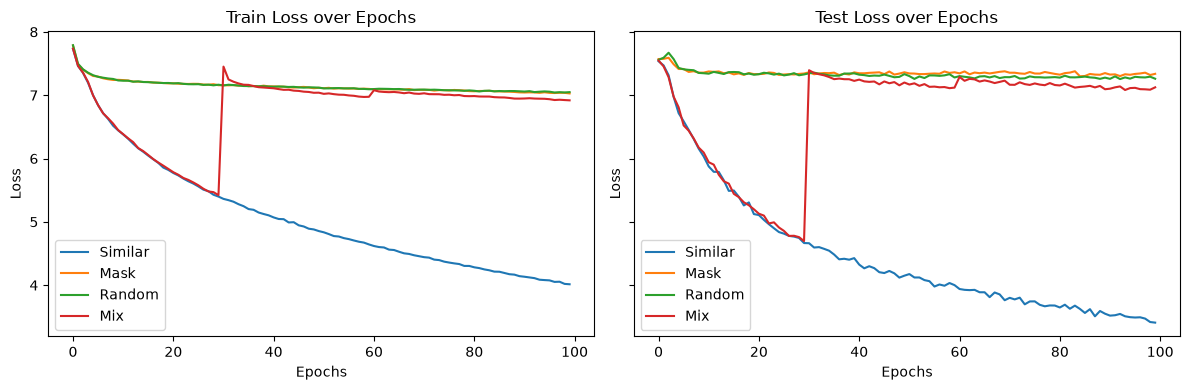

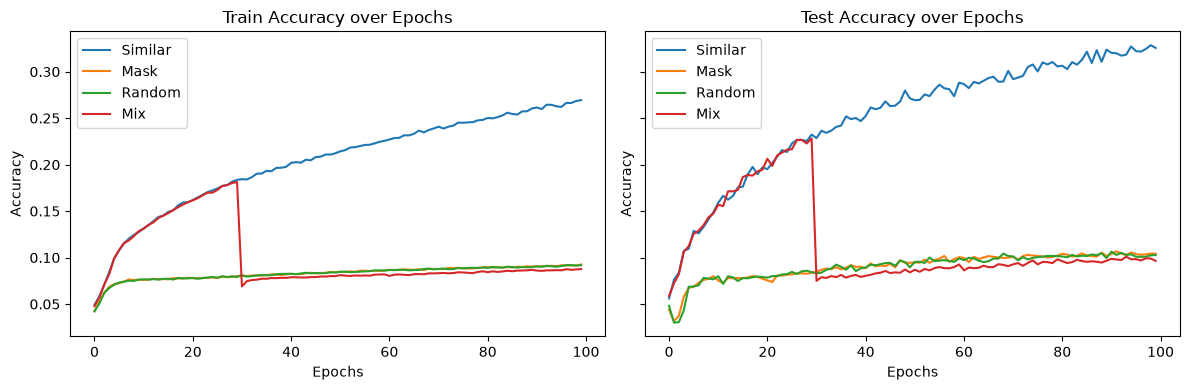

In [10]:
plot_train_test_metric(results_one_step, "loss", ylabel="Loss")
plot_train_test_metric(results_one_step, "acc", ylabel="Accuracy")

### Four step denoising training

In [11]:
with open('training_output/similar_100_4_steps.json', 'r') as file:
    similar_4_steps = json.loads(file.read())

with open('training_output/mask_100_4_steps.json', 'r') as file:
    mask_4_steps = json.loads(file.read())
    
with open('training_output/random_100_4_steps.json', 'r') as file:
    random_4_steps = json.loads(file.read())
    
with open('training_output/mix_30_30_40_4_steps.json', 'r') as file:
    mix_4_steps = json.loads(file.read())

In [12]:
mean_similar_4_steps = get_mean_by_epoch(similar_4_steps)
mean_mask_4_steps = get_mean_by_epoch(mask_4_steps)
mean_random_4_steps = get_mean_by_epoch(random_4_steps)
mean_mix_4_steps = get_mean_by_epoch(mix_4_steps)

In [13]:
results_4_steps = {
    "Similar": mean_similar_4_steps,
    "Mask": mean_mask_4_steps,
    "Random": mean_random_4_steps,
    "Mix": mean_mix_4_steps
}

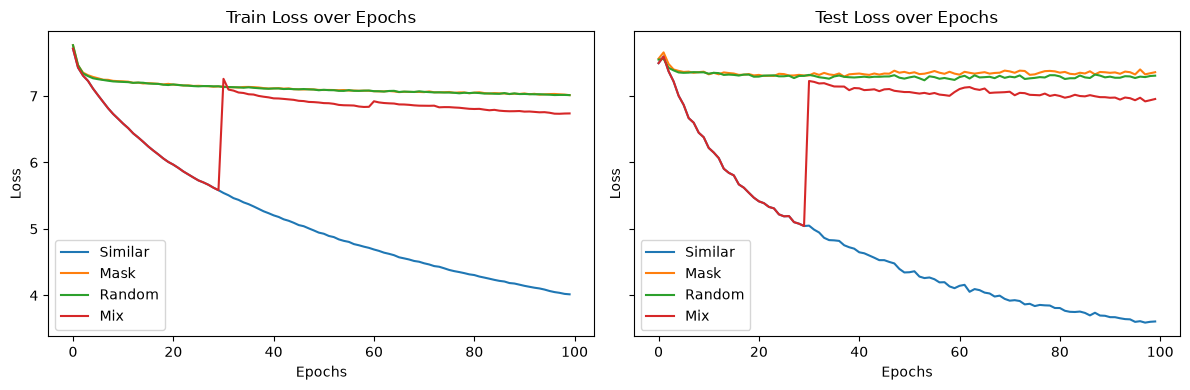

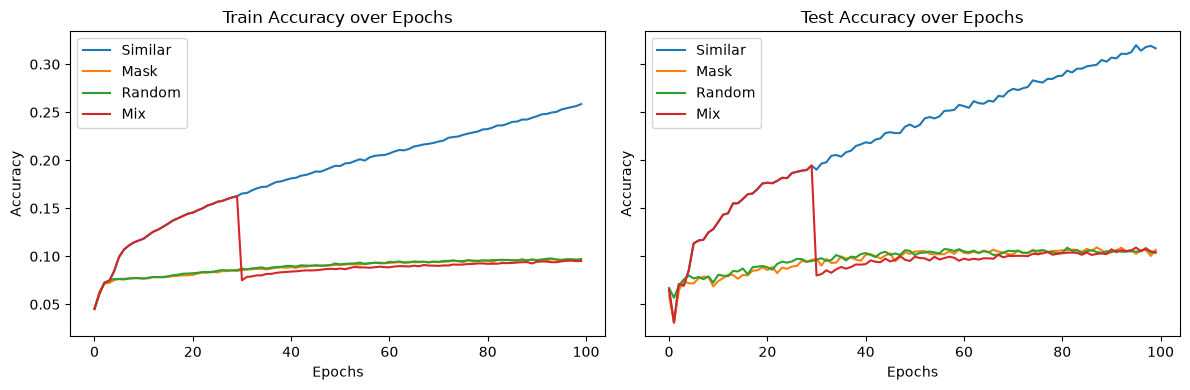

In [14]:
plot_train_test_metric(results_4_steps, "loss", ylabel="Loss")
plot_train_test_metric(results_4_steps, "acc", ylabel="Accuracy")

### One step vs four steps 

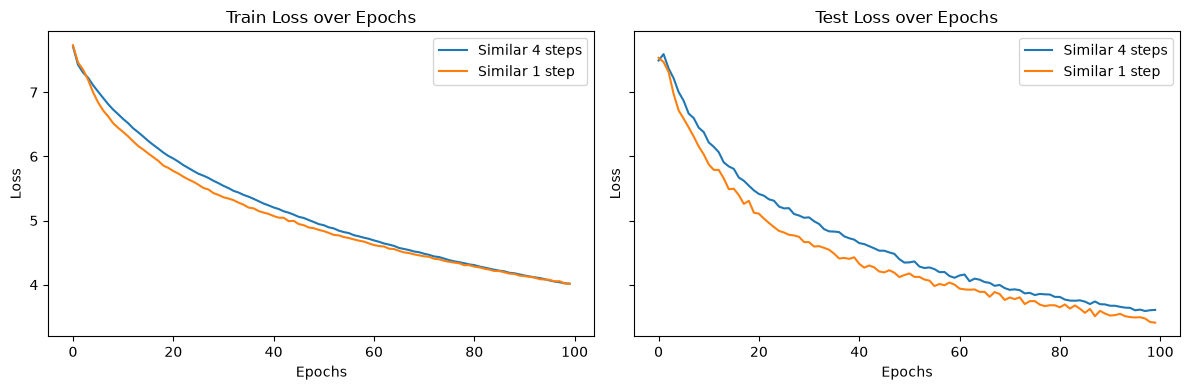

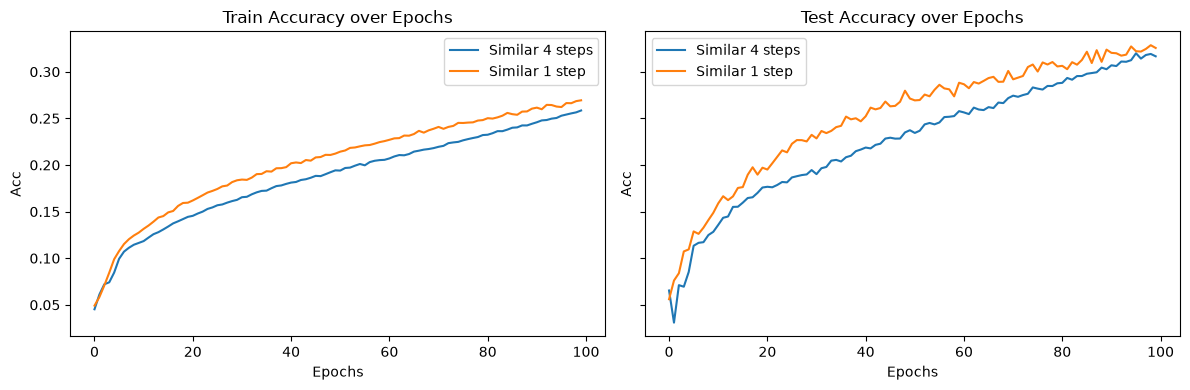

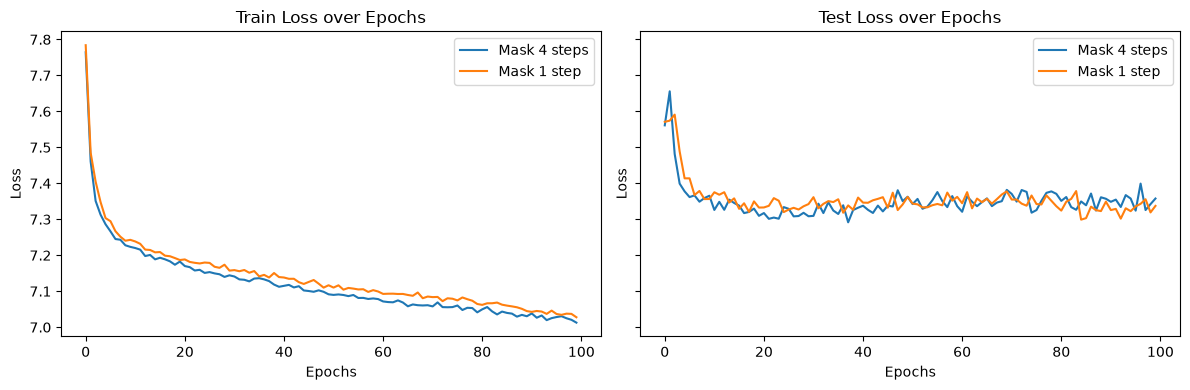

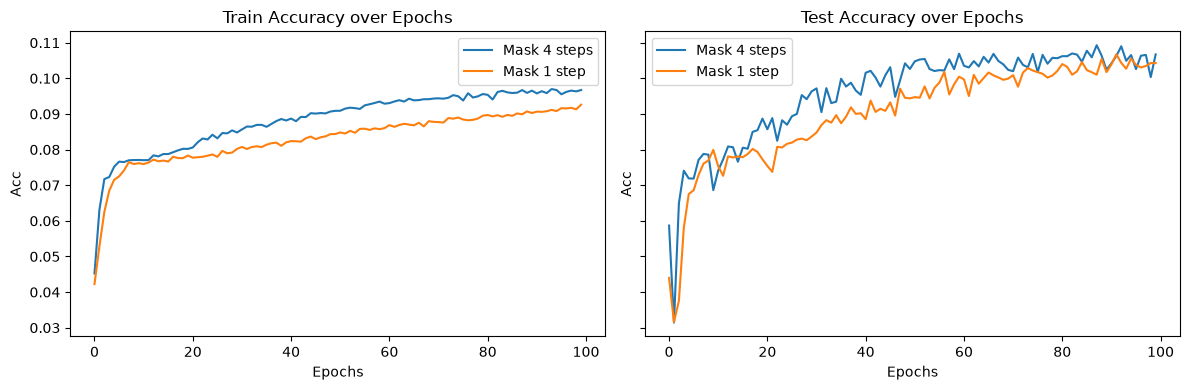

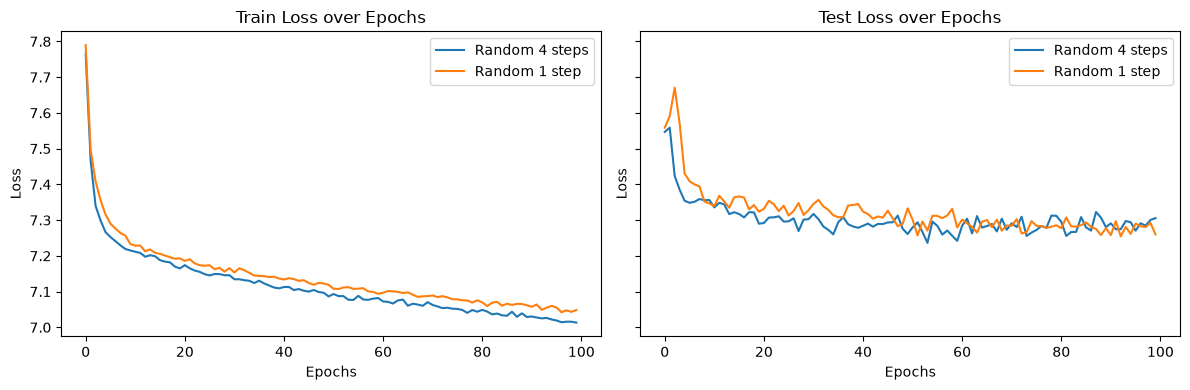

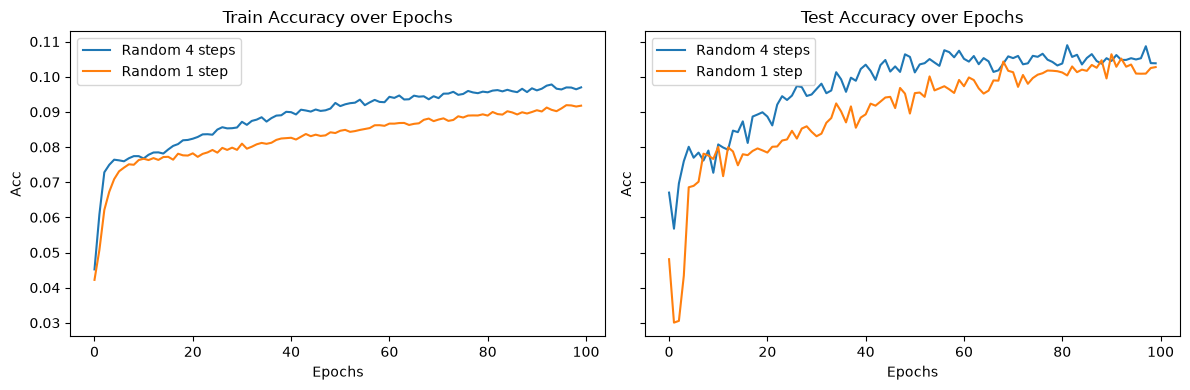

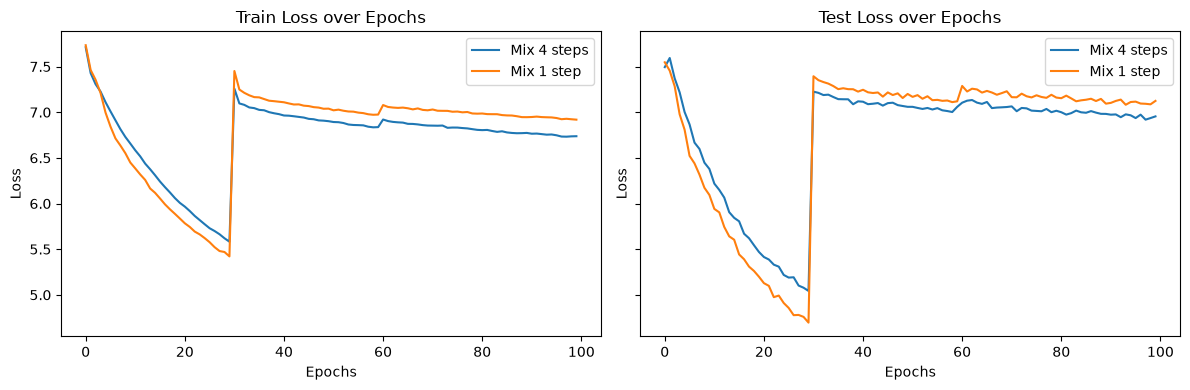

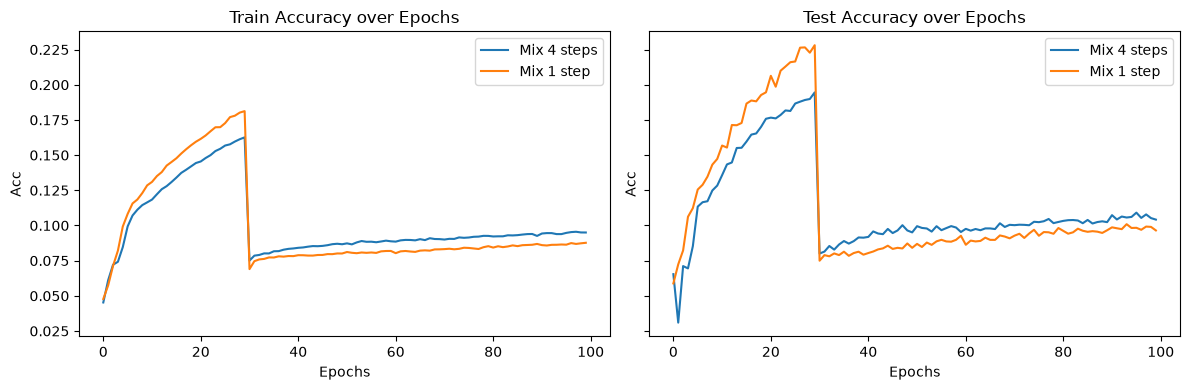

In [15]:
all_results = [
    {
        "Similar 4 steps": mean_similar_4_steps,
        "Similar 1 step": mean_similar_one_step
    },
    {
        "Mask 4 steps": mean_mask_4_steps,
        "Mask 1 step": mean_mask_one_step
    },
    {
        "Random 4 steps": mean_random_4_steps,
        "Random 1 step": mean_random_one_step
    },
    {
        "Mix 4 steps": mean_mix_4_steps,
        "Mix 1 step": mean_mix_one_step
    }
]
metrics = ["loss", "acc"]
for result in all_results:
    for metric in metrics:
        plot_train_test_metric(result, metric, ylabel=metric.capitalize())


## Evaluation results

### Compare 50 step denoising between models after one step denoising training

In [16]:
df = pd.read_json('eval/evaluation_results_50.json')

In [17]:
def compare_models_by_method(df, corruption_method, corruption_rate, metrics = ['loss', 'accuracy', 'accuracy_denoising']):
    models = df.model.unique()
    df = df[(df['corruption_method'] == corruption_method) & (df['corruption_rate'] == corruption_rate)]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Comparison of Models by {corruption_method.capitalize()} Corruption (Rate: {int(corruption_rate * 100)}%)')
    for i, metric in enumerate(metrics):
        model_names = [model.split('_')[0] if '_' in model else model for model in models]
        axes[i].bar(x=model_names, height=df[metric])
        axes[i].set_title(f'{metric.capitalize()}')

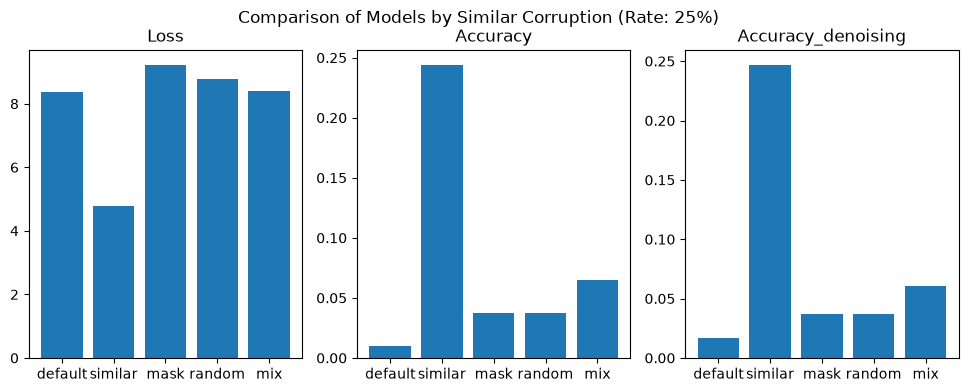

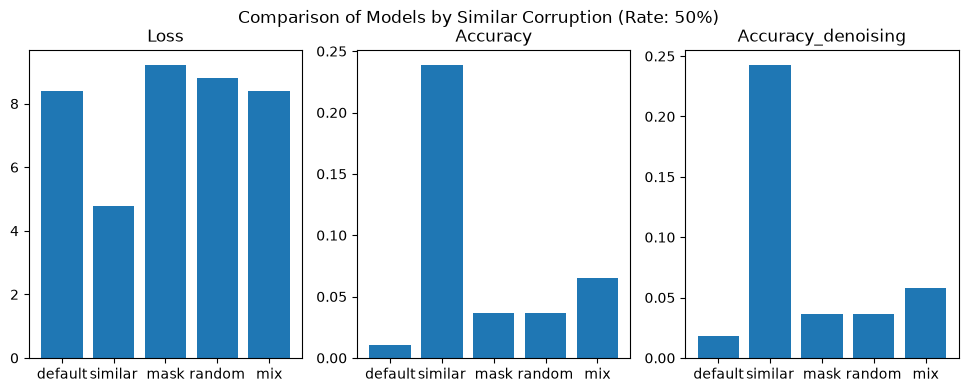

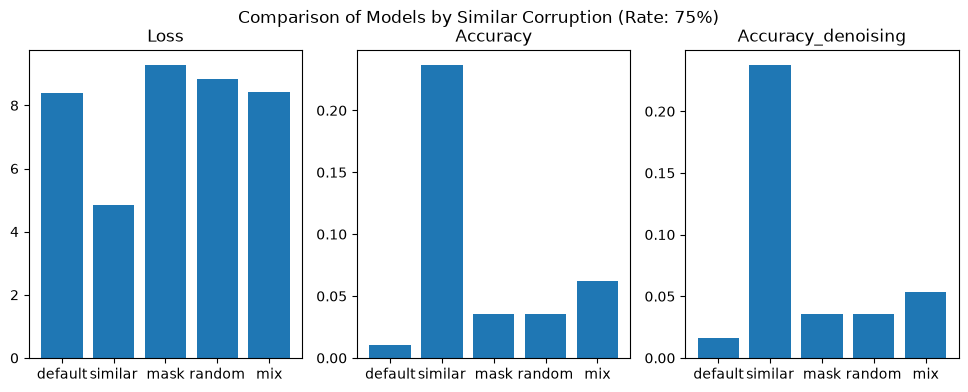

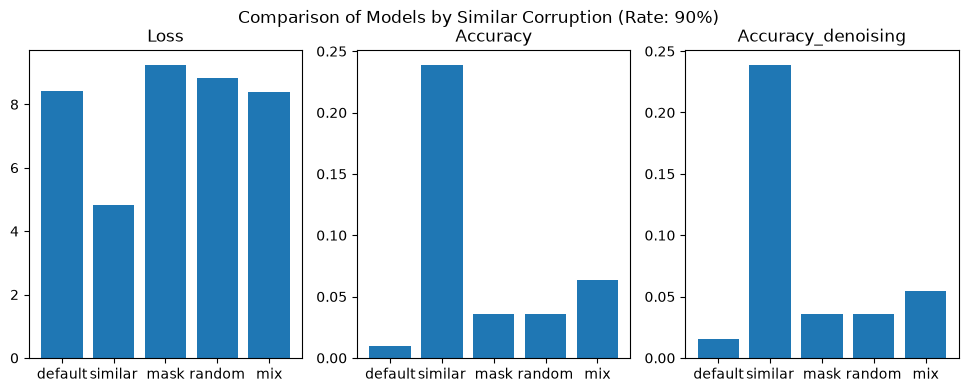

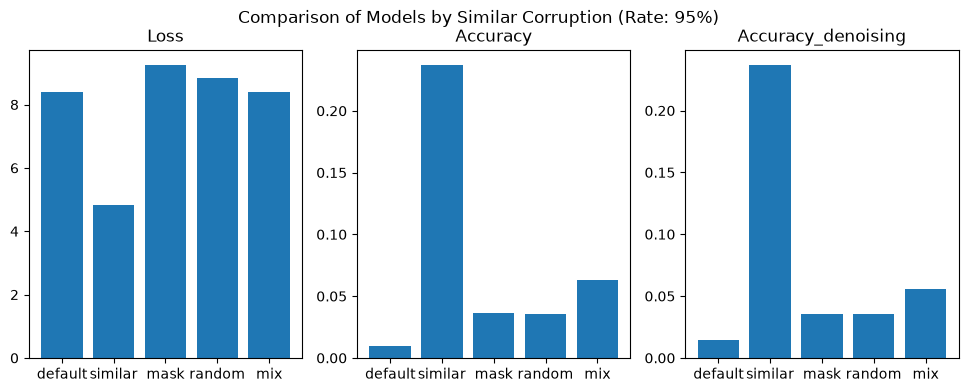

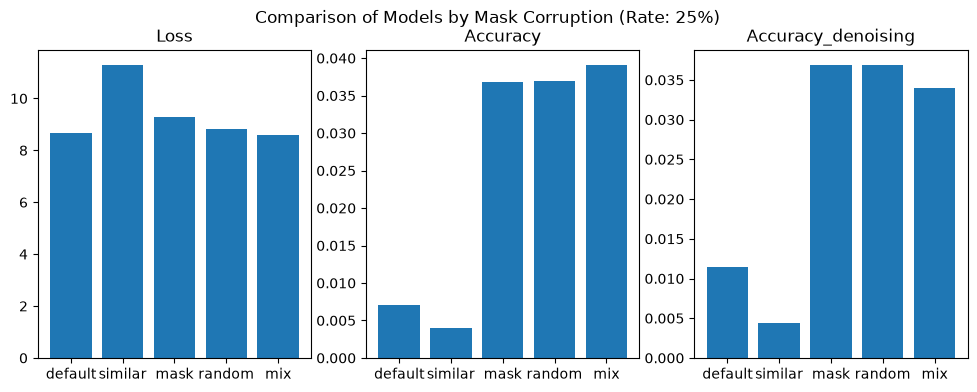

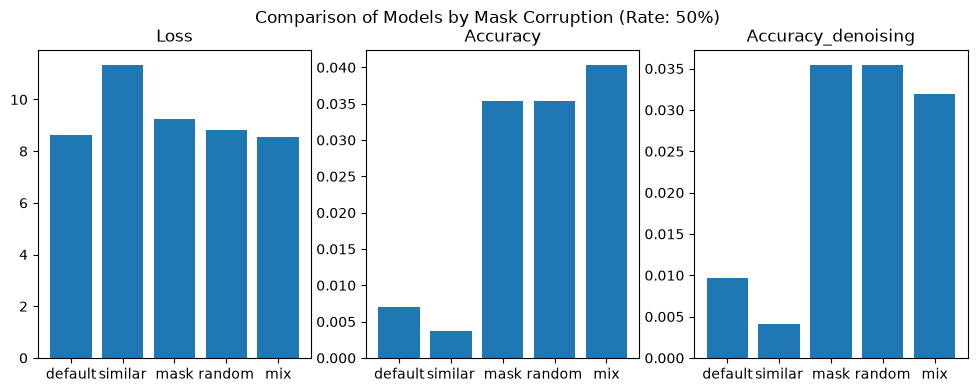

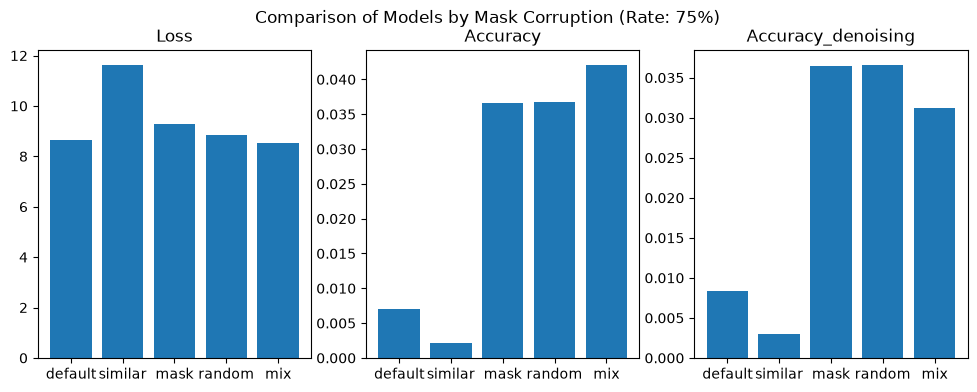

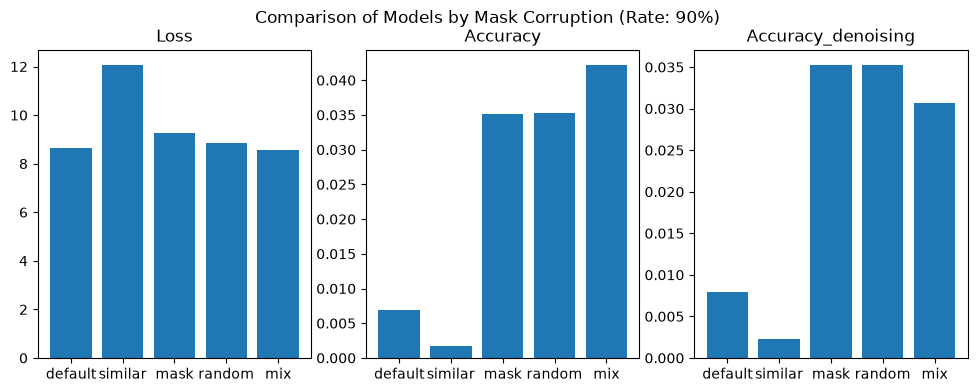

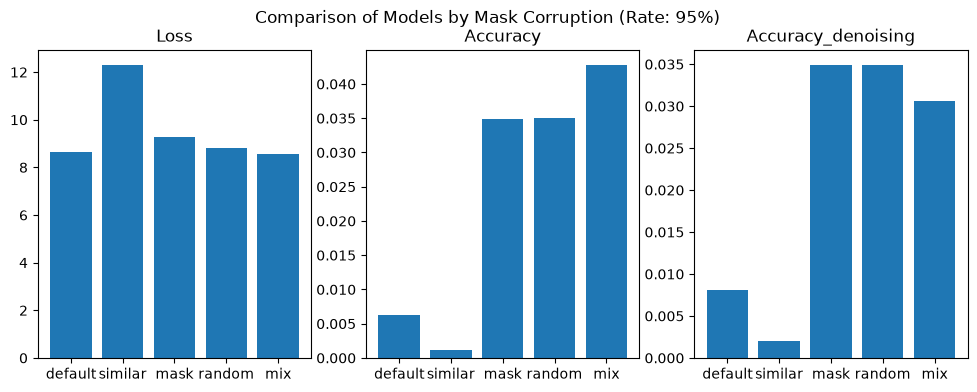

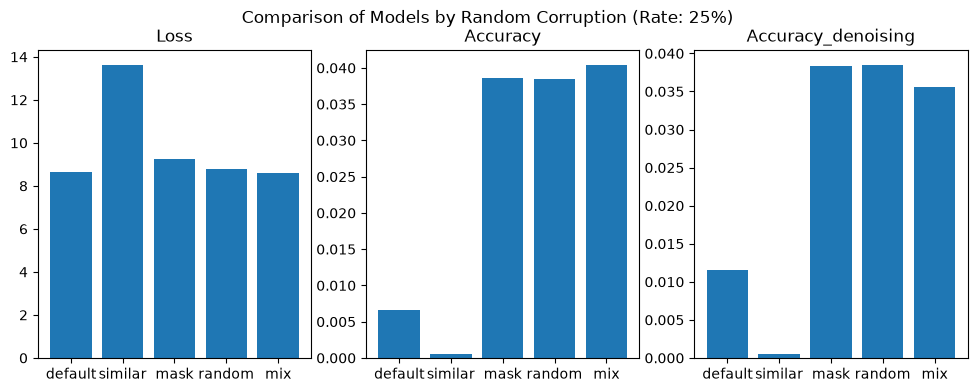

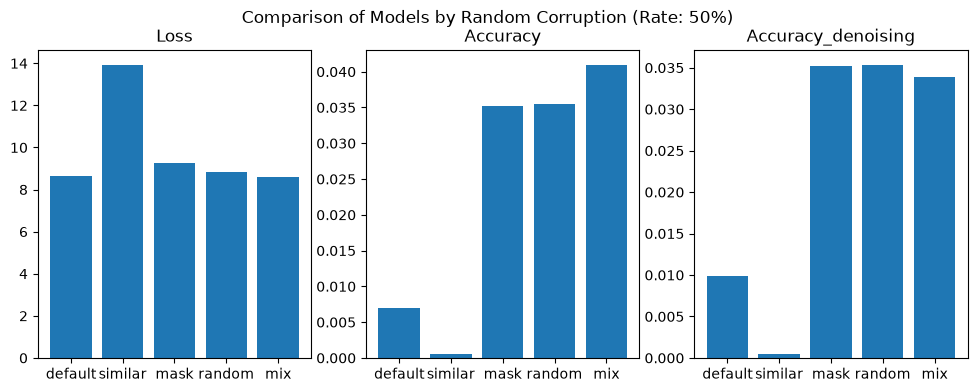

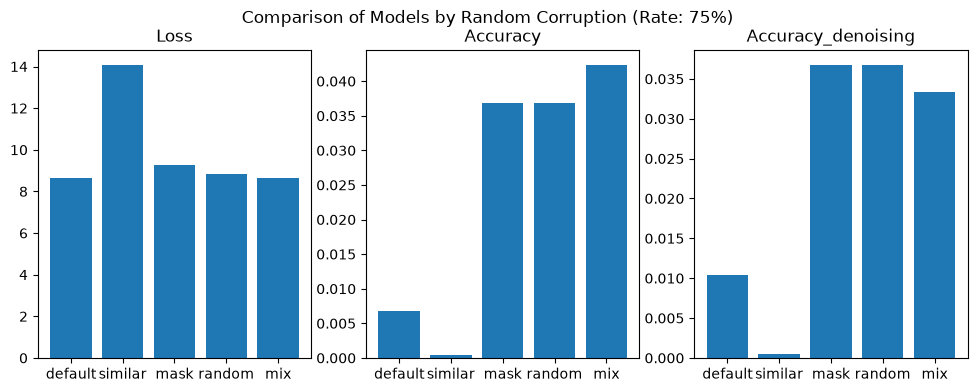

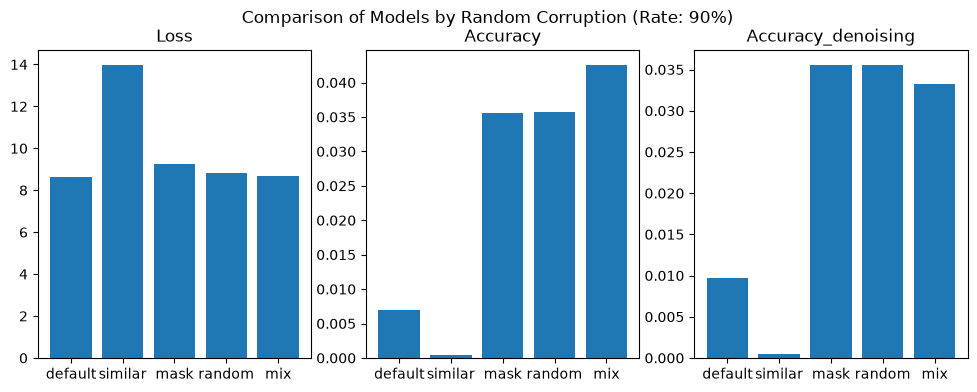

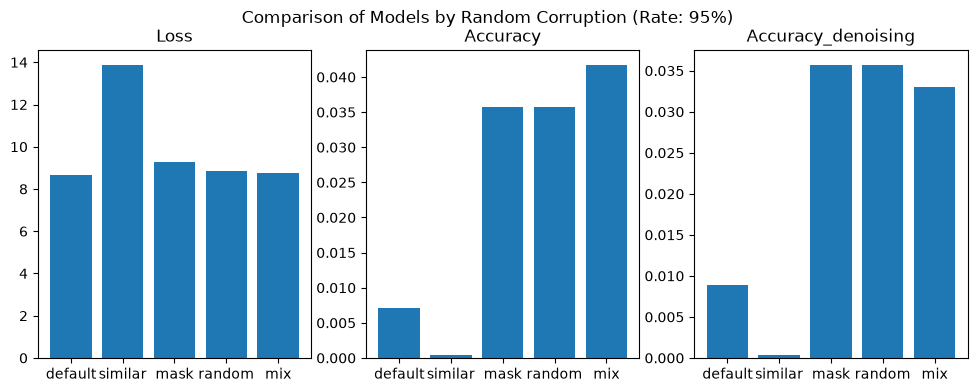

In [18]:
for corruption_method in df['corruption_method'].unique():
    for corruption_rate in df['corruption_rate'].unique():
        compare_models_by_method(df, corruption_method, corruption_rate)

### Compare 50 step denoising between models after 4 denoising training

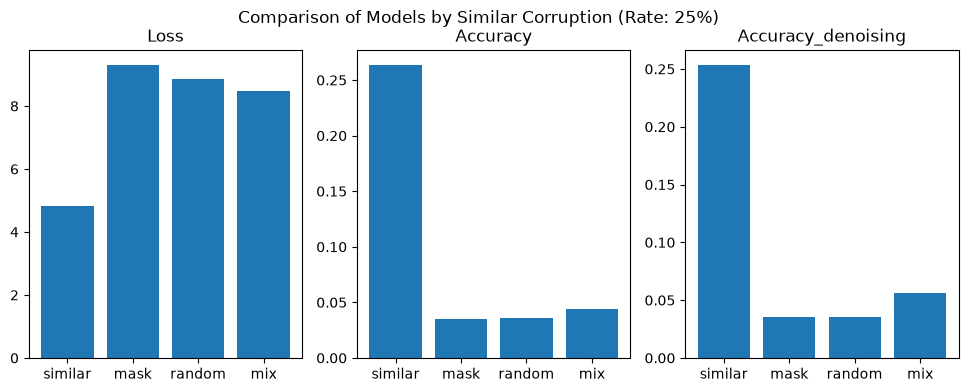

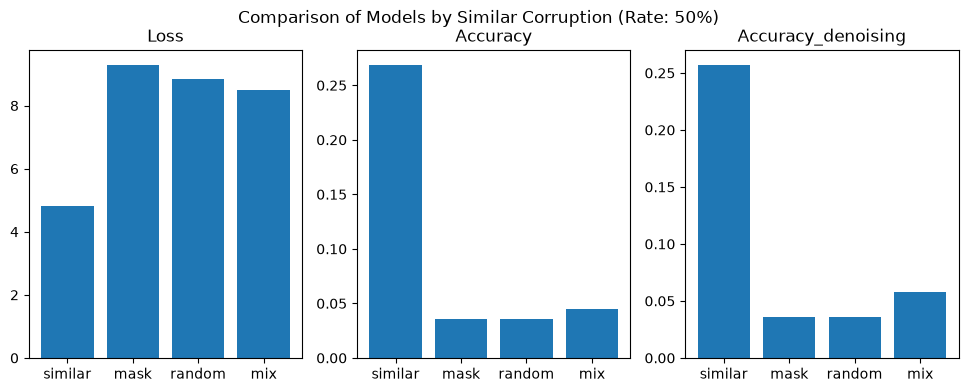

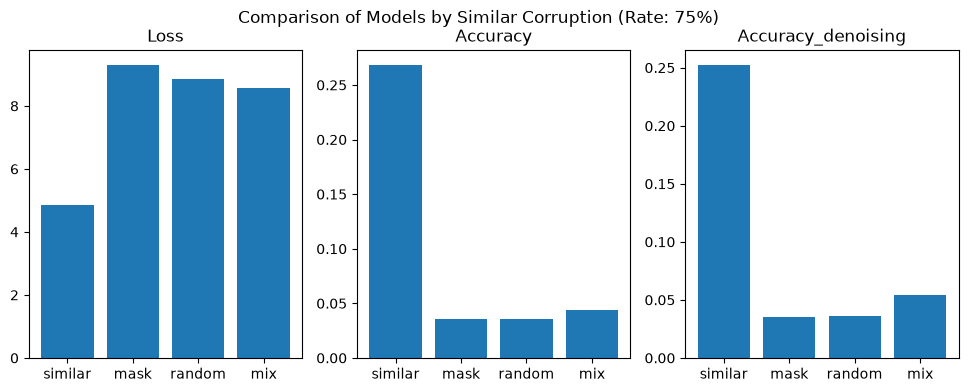

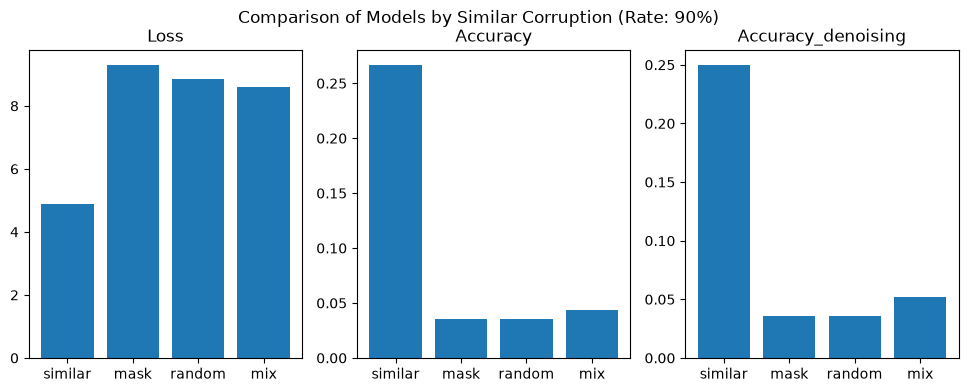

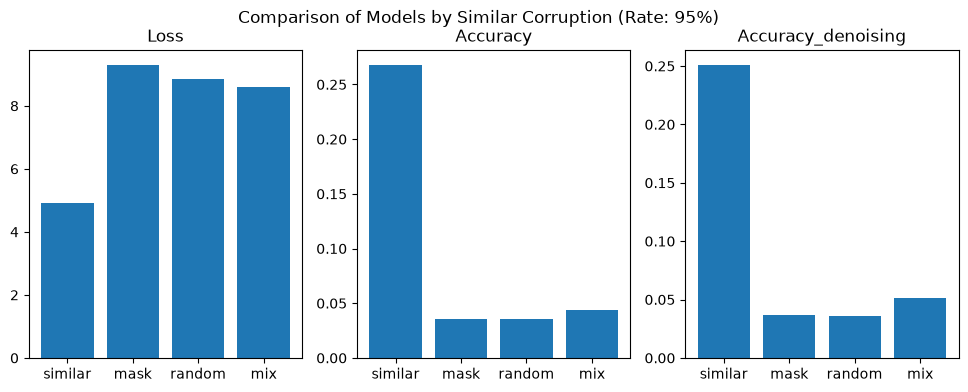

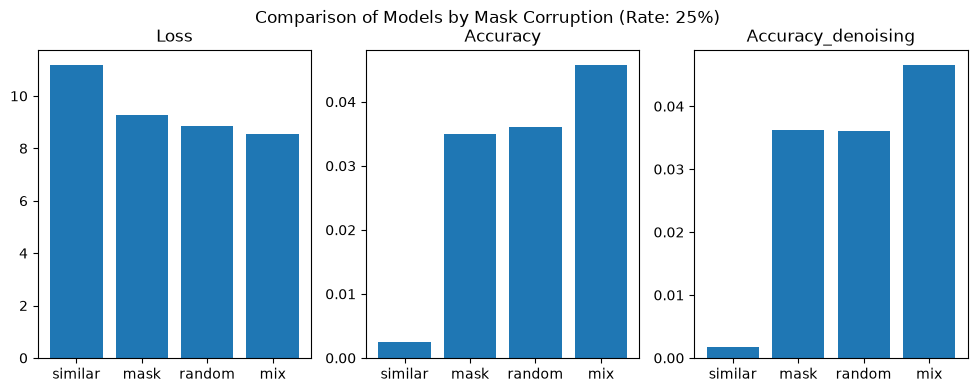

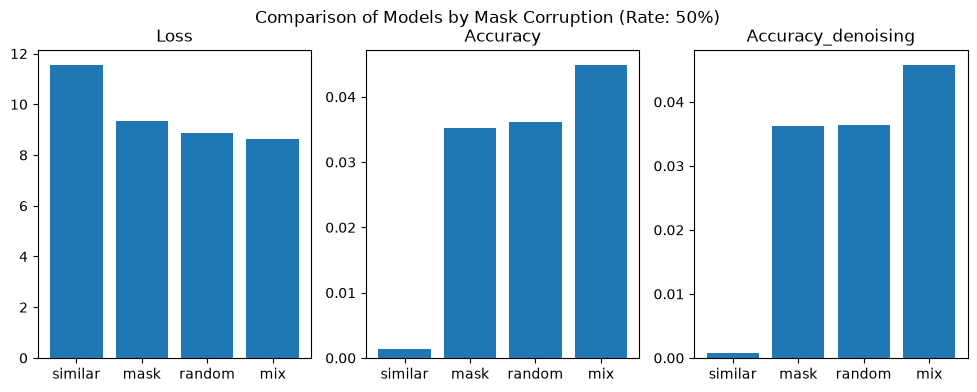

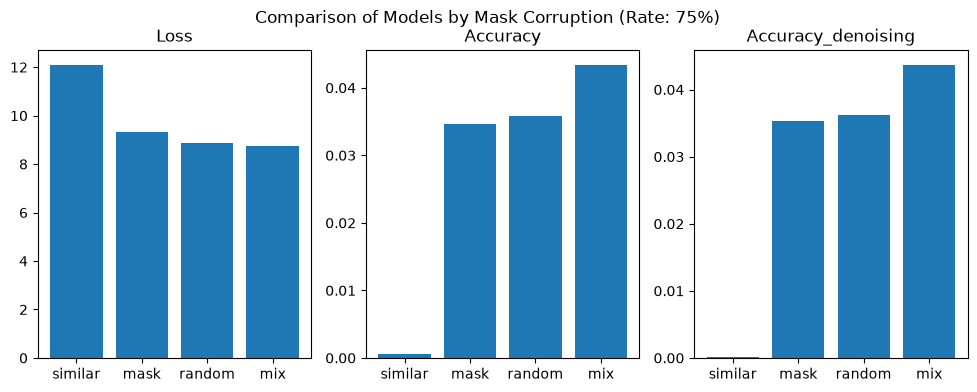

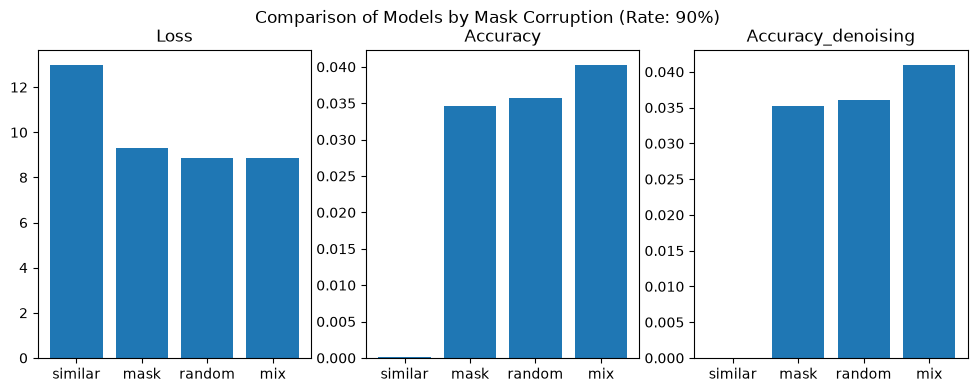

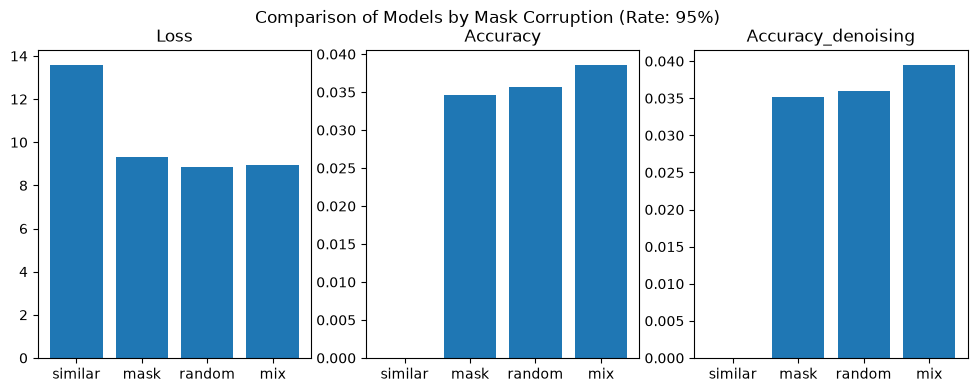

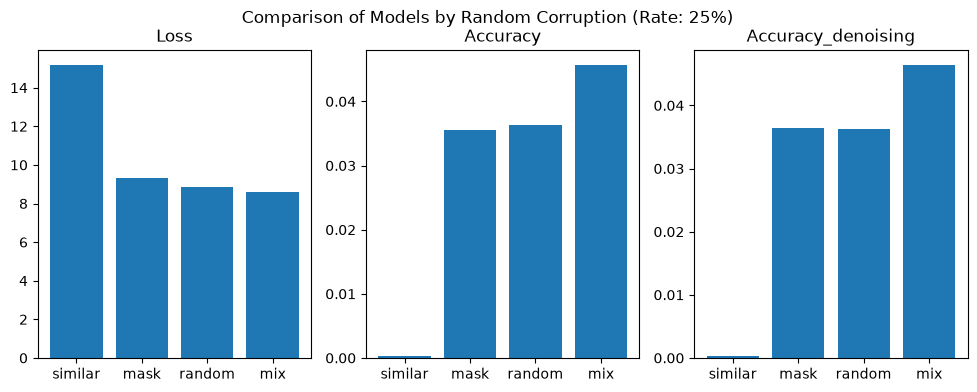

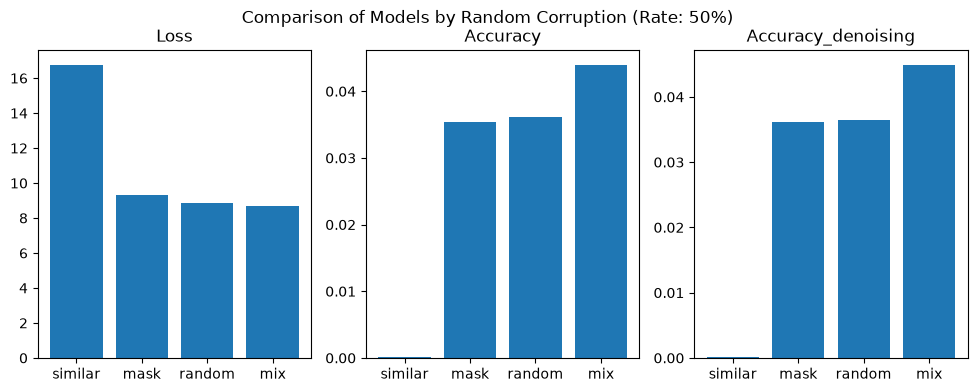

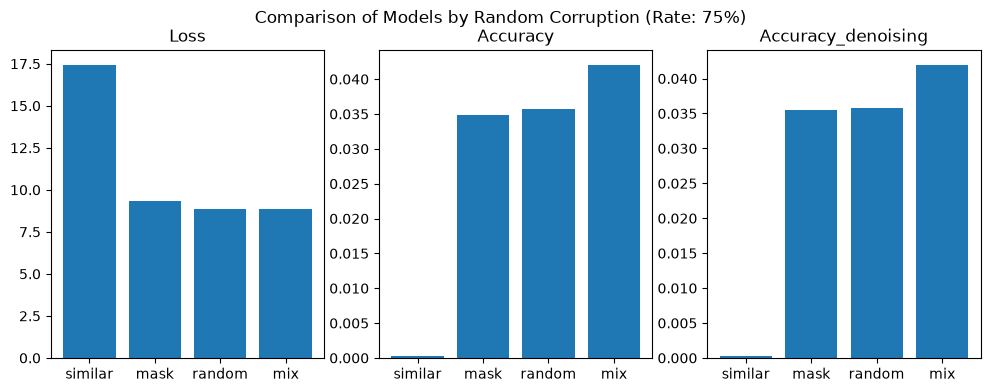

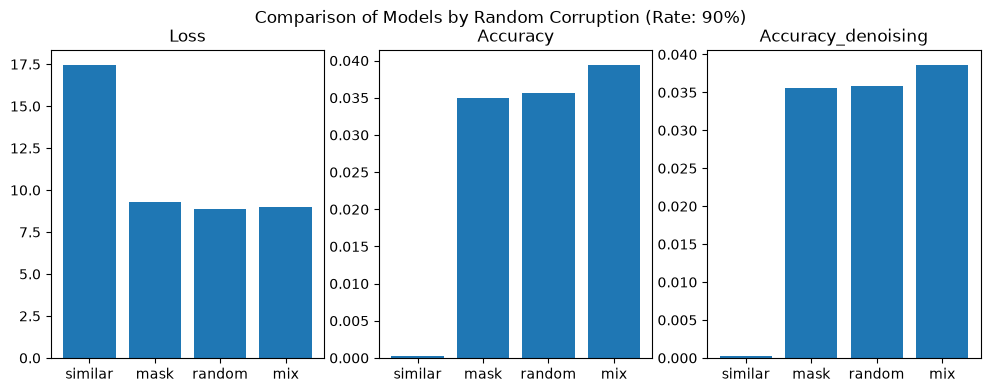

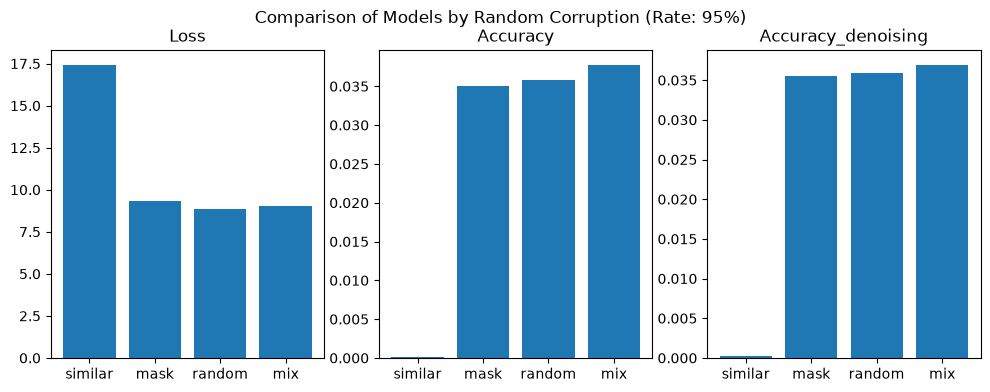

In [21]:
df = pd.read_json('eval/evaluation_results_50_4_steps.json')

for corruption_method in df['corruption_method'].unique():
    for corruption_rate in df['corruption_rate'].unique():
        compare_models_by_method(df, corruption_method, corruption_rate)

### Compare 50 step denoising between models after 4 and 1 step denoising training

In [135]:
df_1_step = pd.read_json('eval/evaluation_results_50.json')
df_4_steps = pd.read_json('eval/evaluation_results_50_4_steps.json')

df_1_step = df_1_step[df_1_step.model != 'default']
df_1_step.model = df_1_step.model.map(lambda x: x.split('_')[0] + '_1' if '_' in x else x)

df_4_steps = df_4_steps[df_4_steps.model != 'default']
df_4_steps.model = df_4_steps.model.map(lambda x: x.split('_')[0] + '_4' if '_' in x else x)

df = pd.concat([df_1_step, df_4_steps], ignore_index=True)
df['denoising_gain'] = df['accuracy_denoising'] - df['accuracy']

In [136]:
POSSIBLE_METRICS = ['loss', 'accuracy', 'accuracy_denoising', 'denoising_gain']

def compare_models_by_one_metric(df, corruption_method, corruption_rate, metric):
    if metric not in POSSIBLE_METRICS:
        raise ValueError(
            f"Invalid metric '{metric}'. Valid metrics are: {POSSIBLE_METRICS}"
        )

    filtered_df = df[
        (df['corruption_method'] == corruption_method) &
        (df['corruption_rate'] == corruption_rate)
    ]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(filtered_df['model'], filtered_df[metric])
    ax.bar_label(
        bars,
        fmt='%.3f',
        padding=3
    )

    ax.set_xlabel('Models')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(
        f'Comparison of Models by {corruption_method.capitalize()} '
        f'Corruption (Rate: {int(corruption_rate * 100)}%)'
    )

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

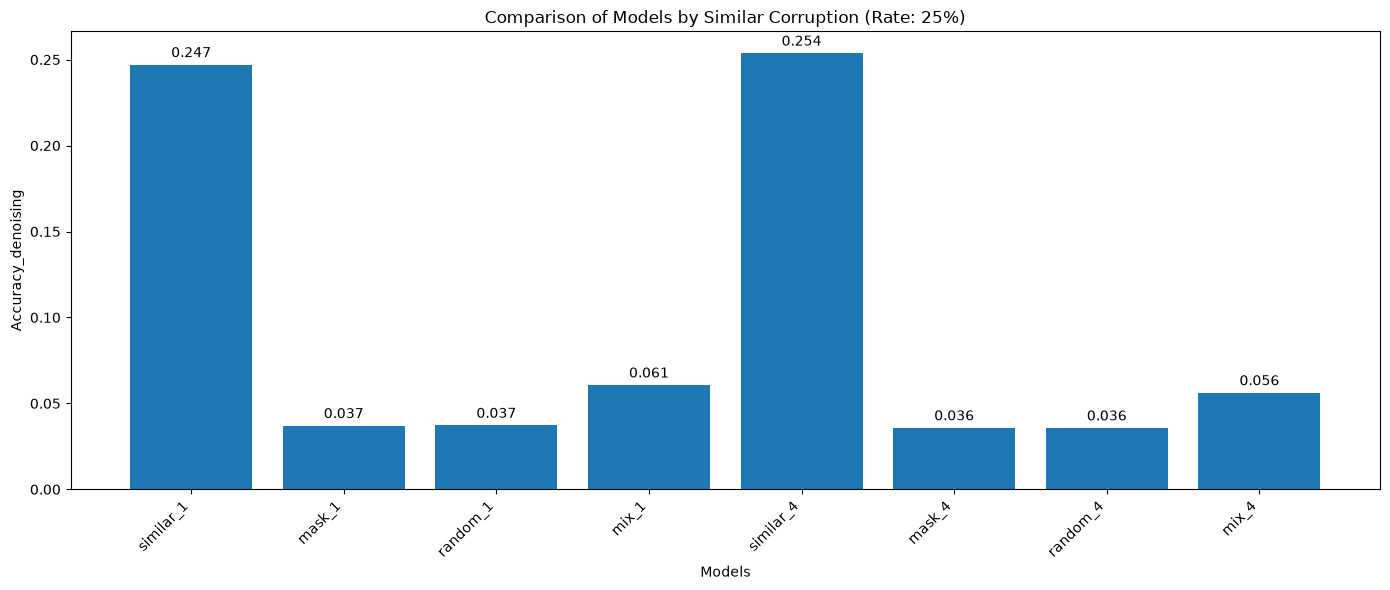

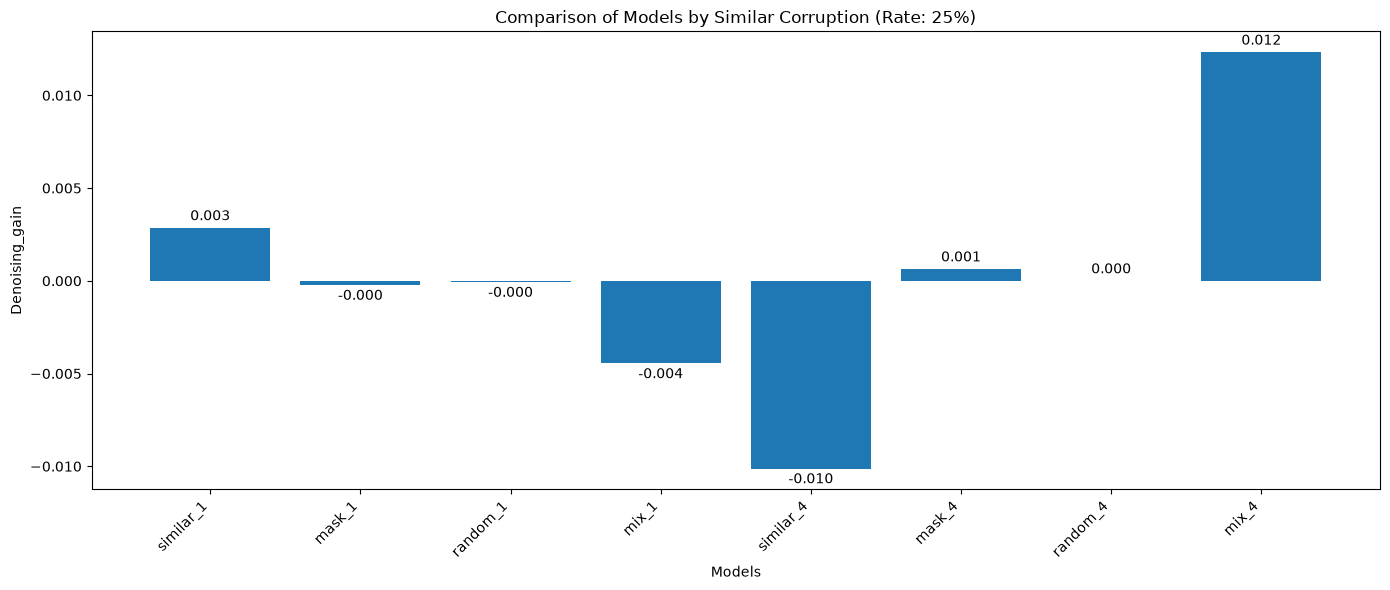

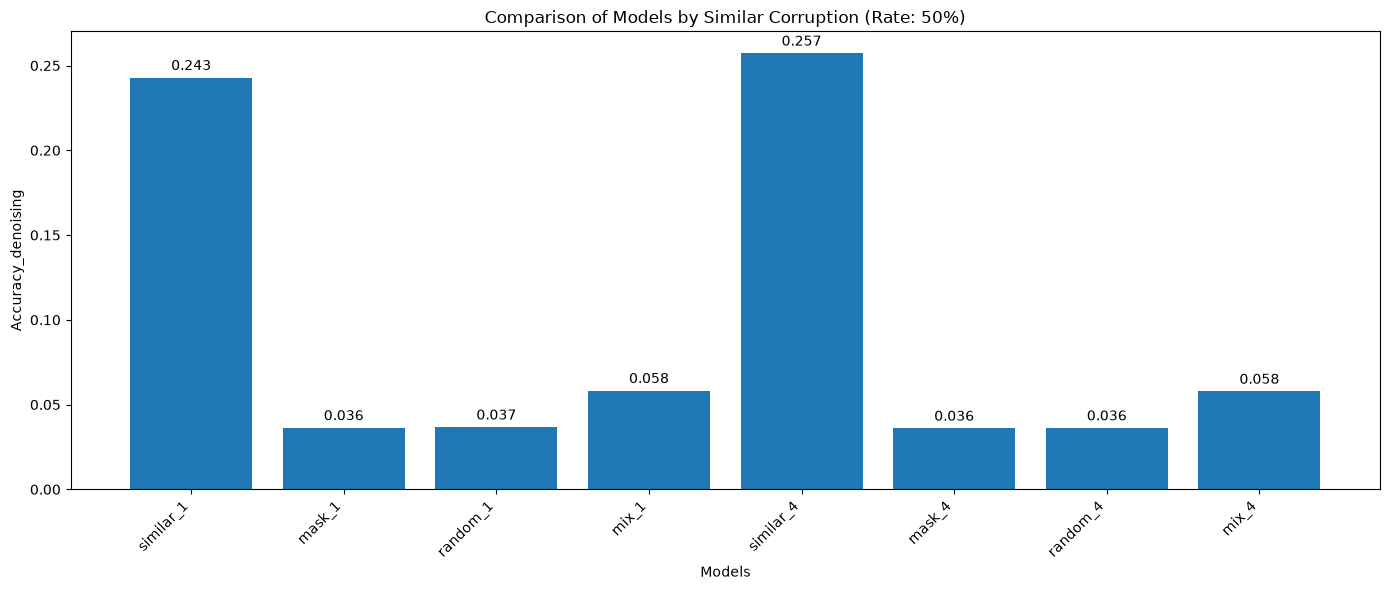

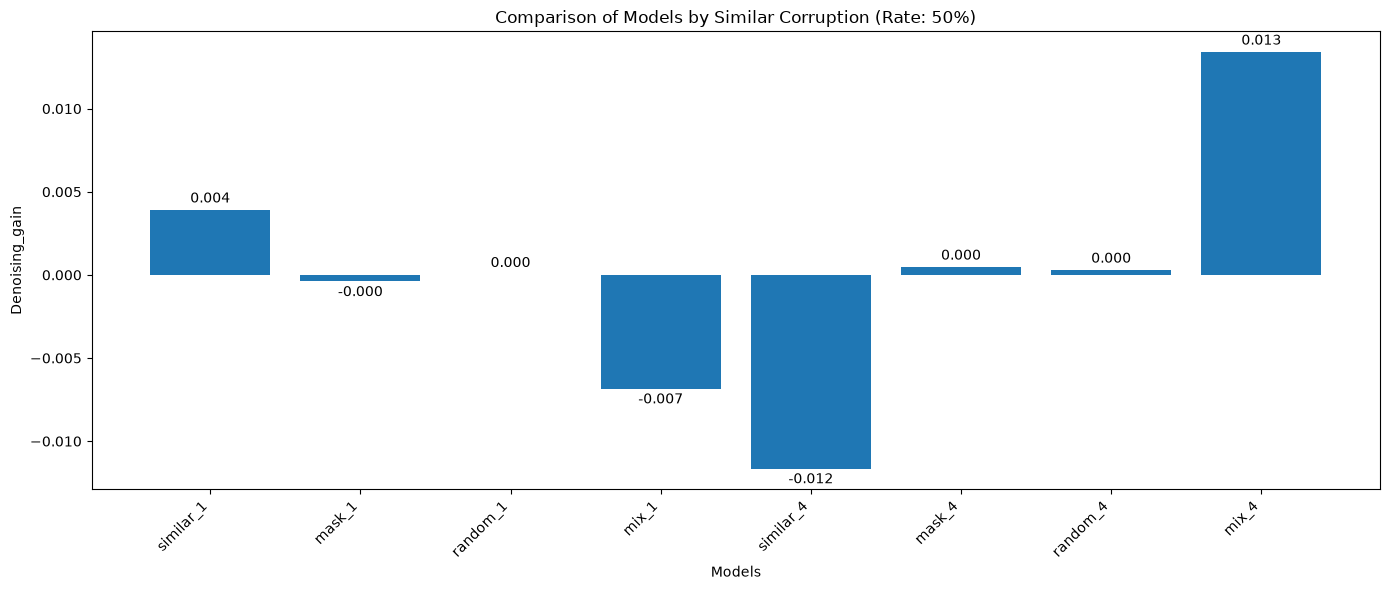

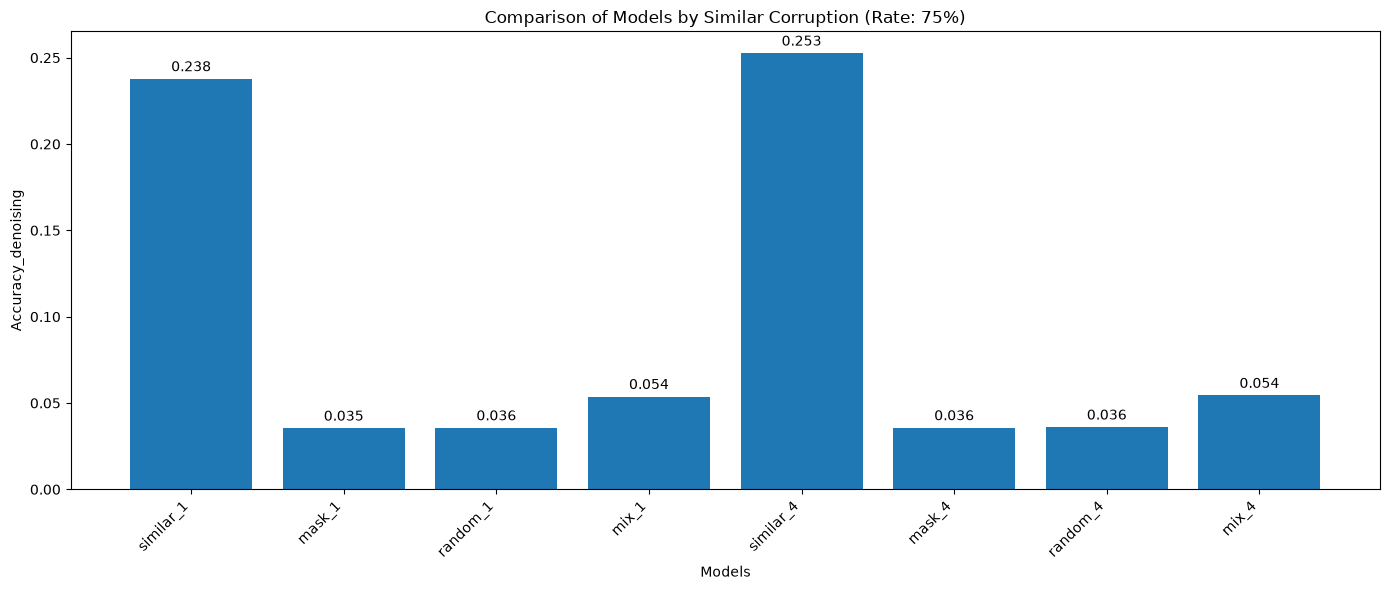

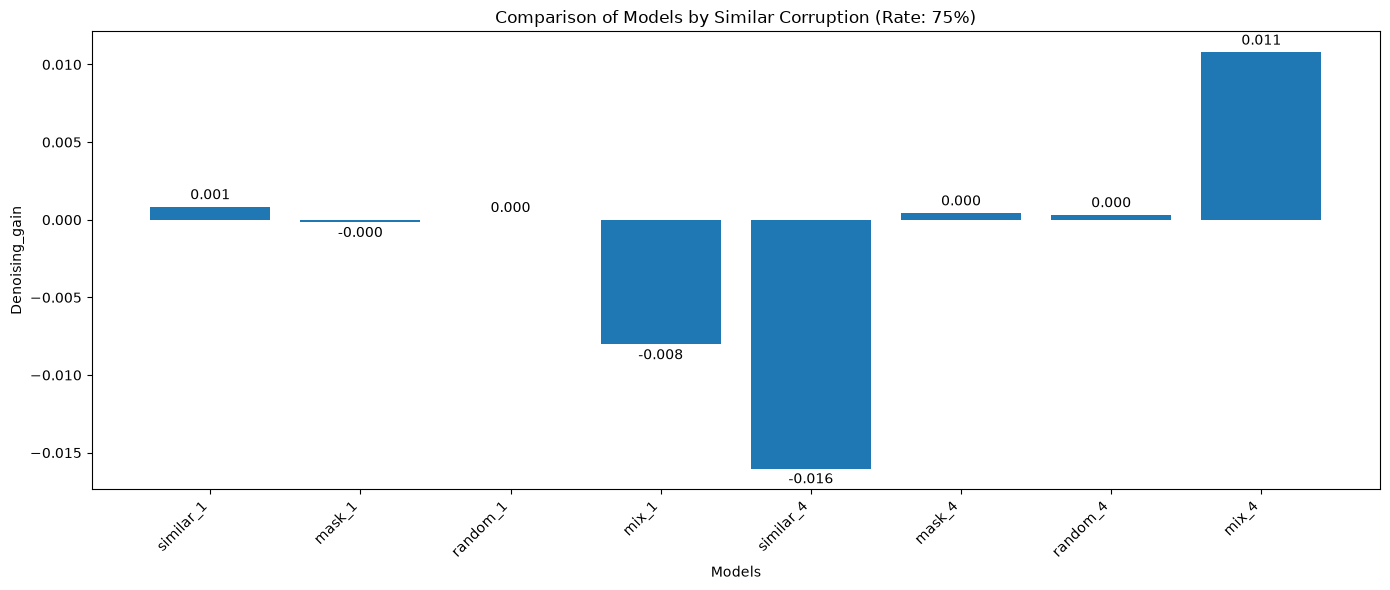

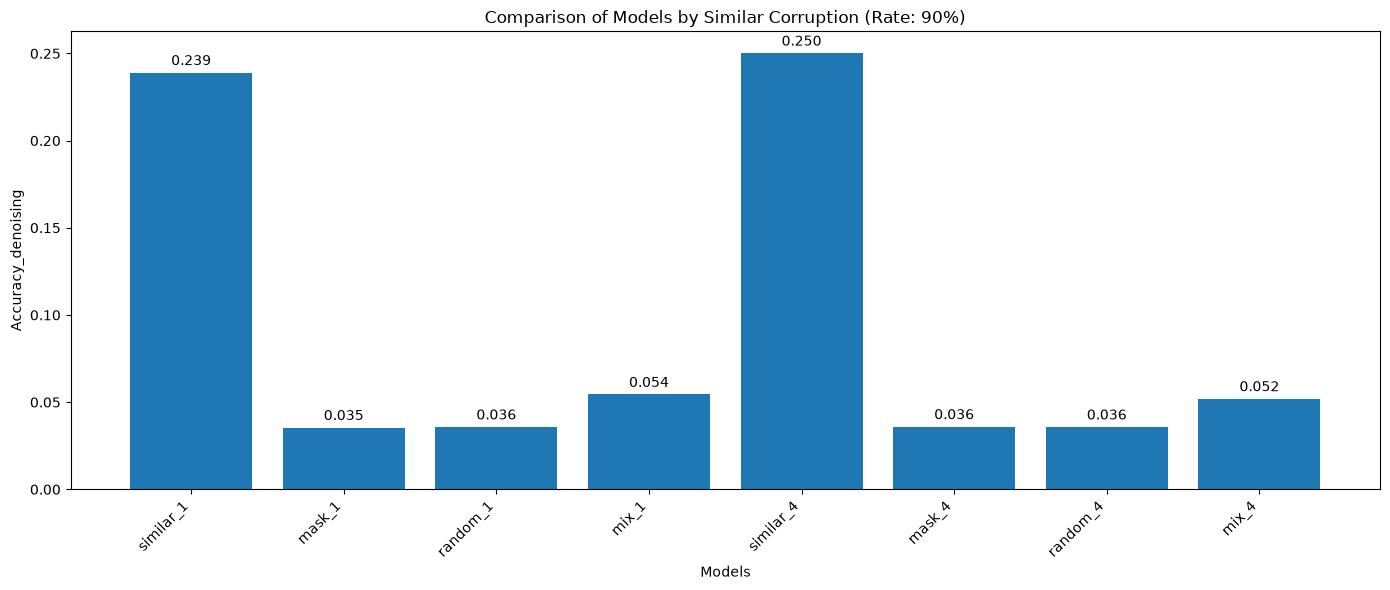

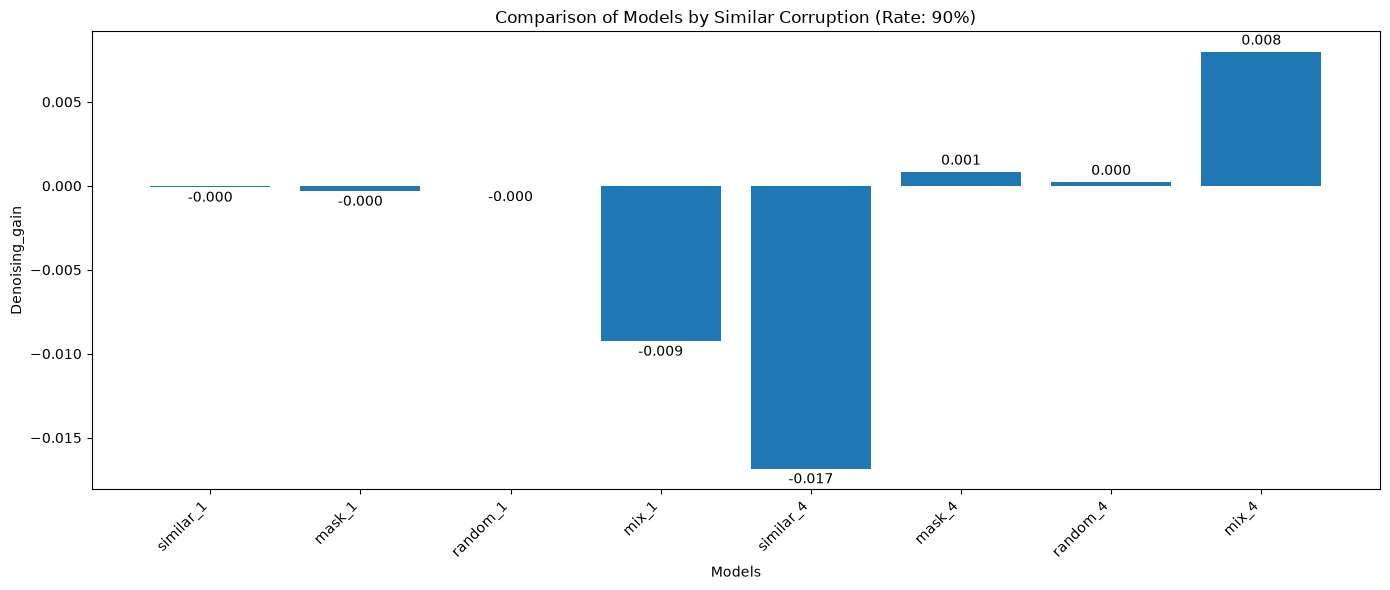

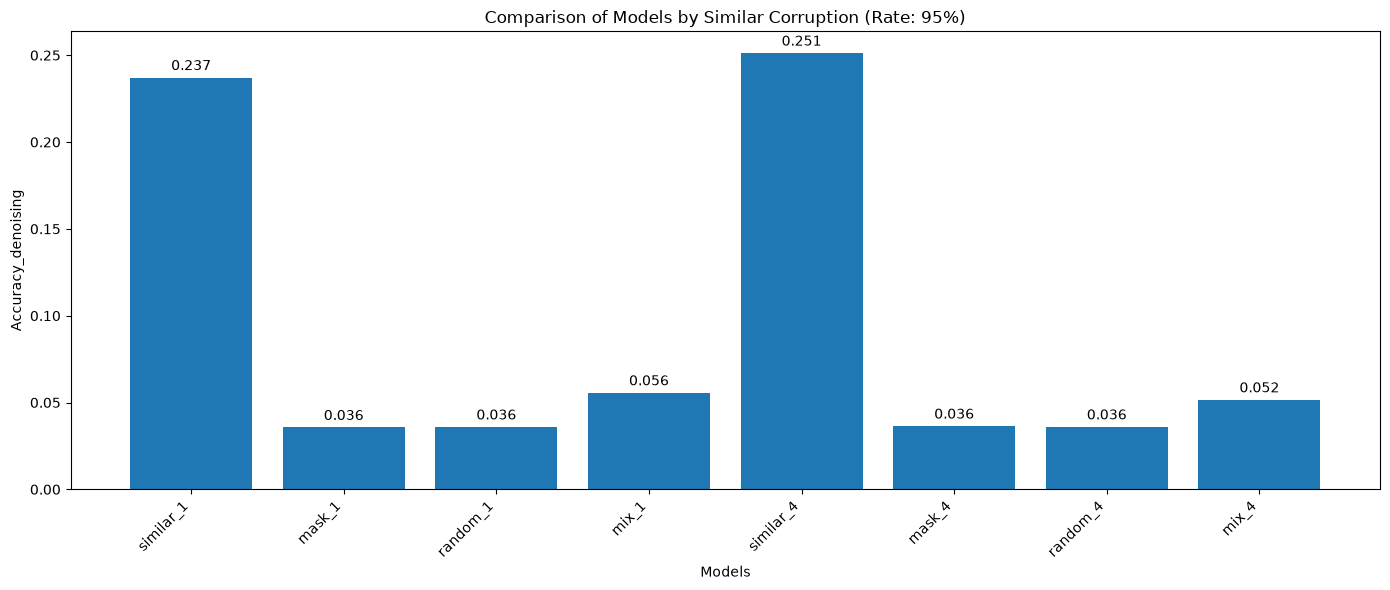

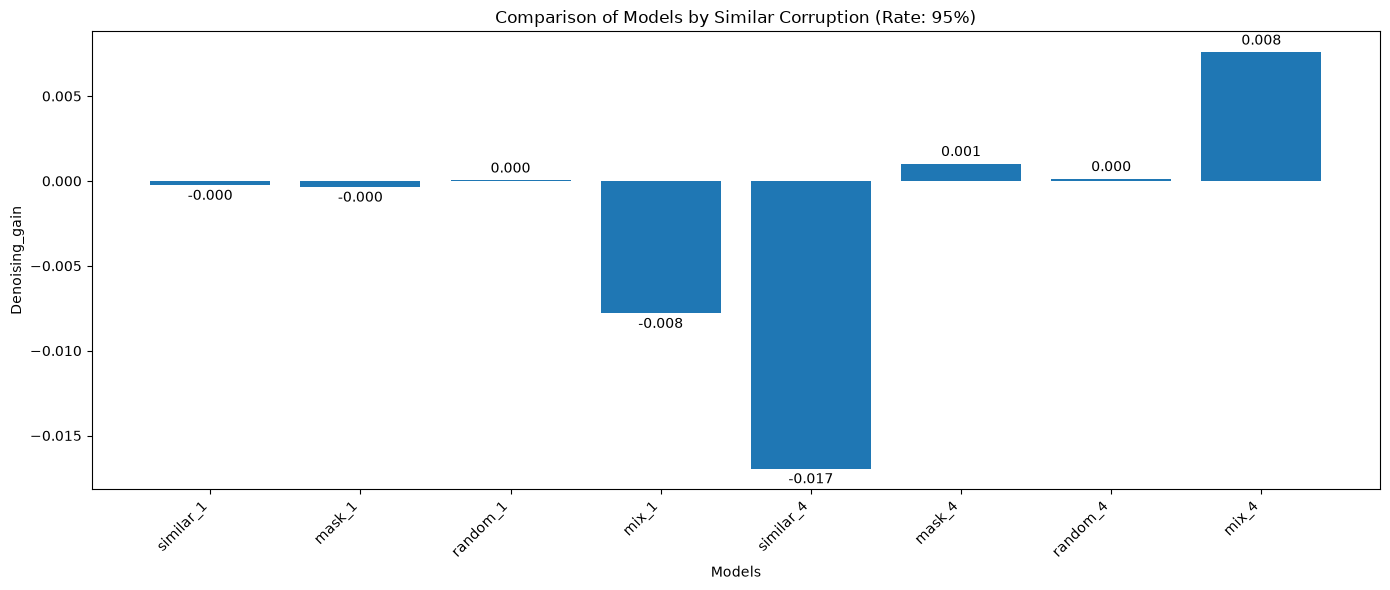

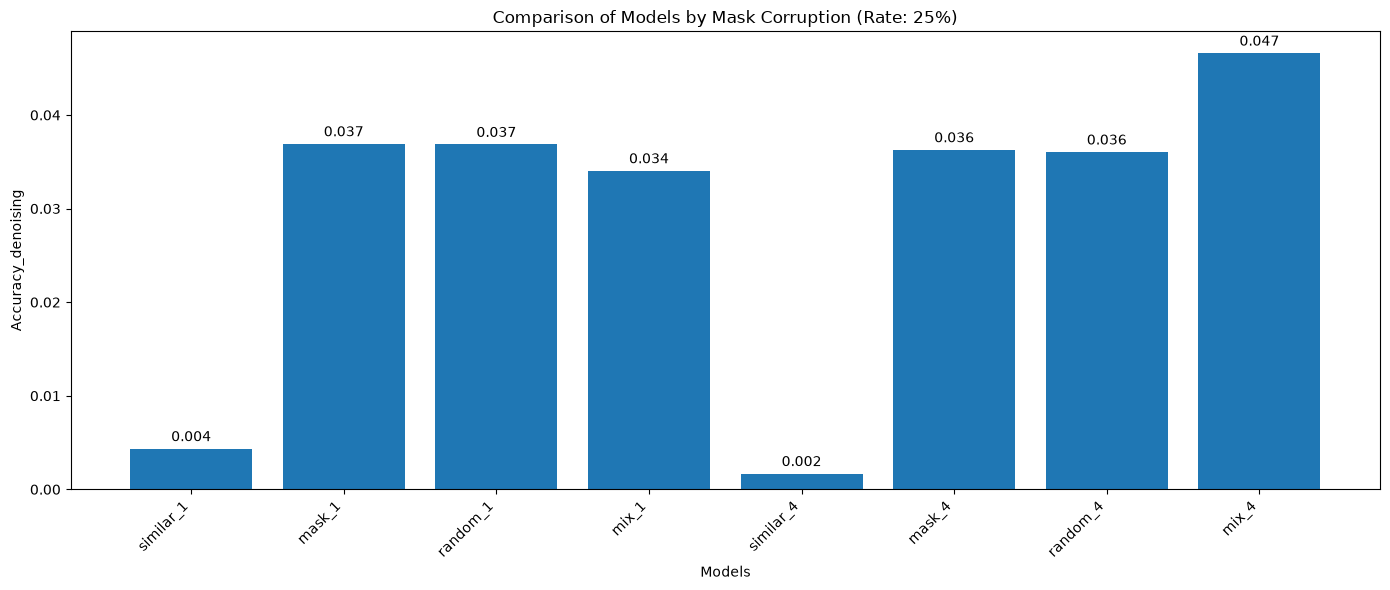

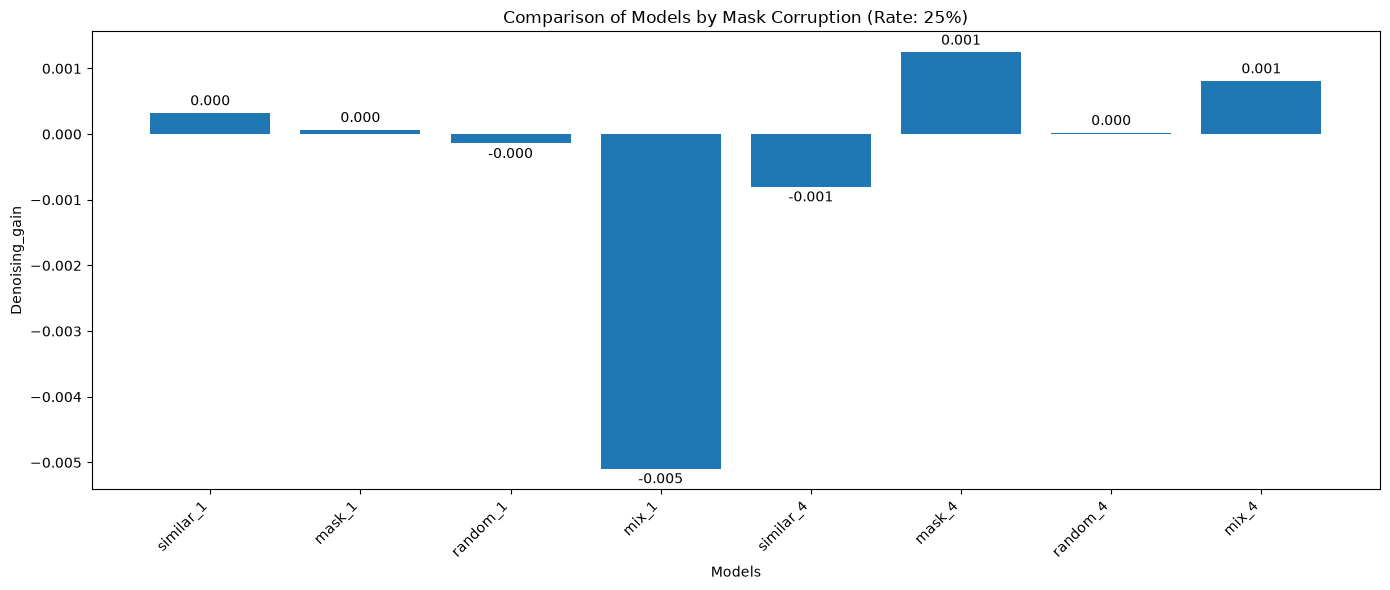

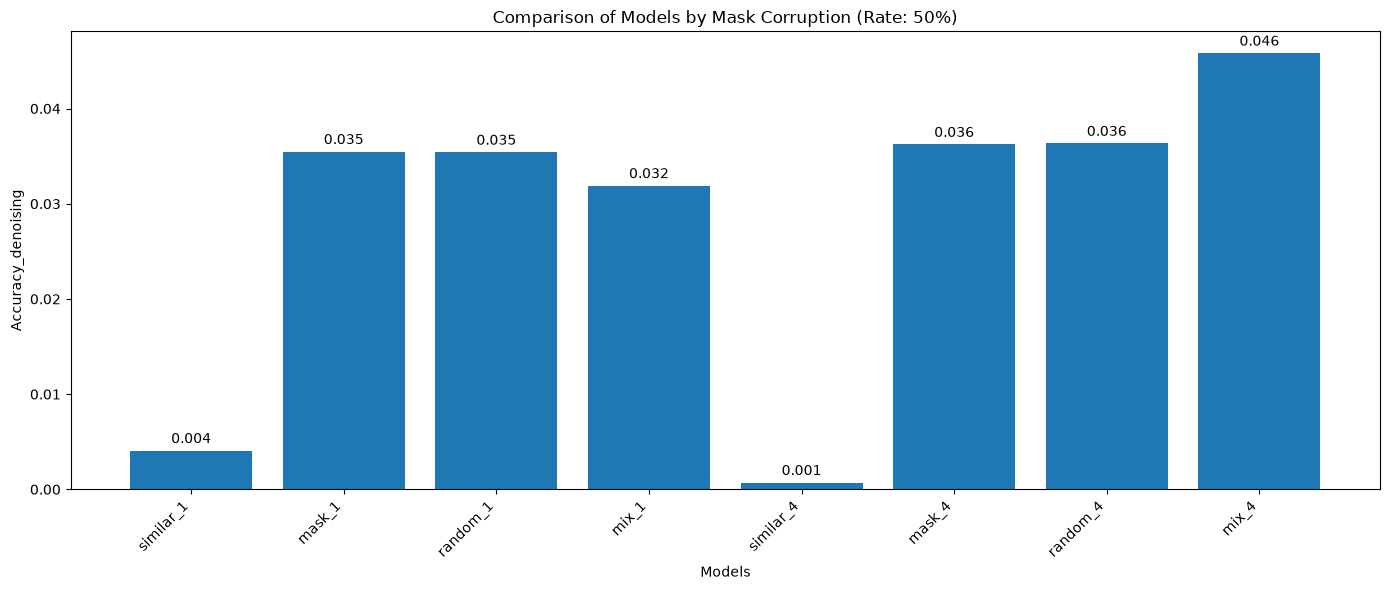

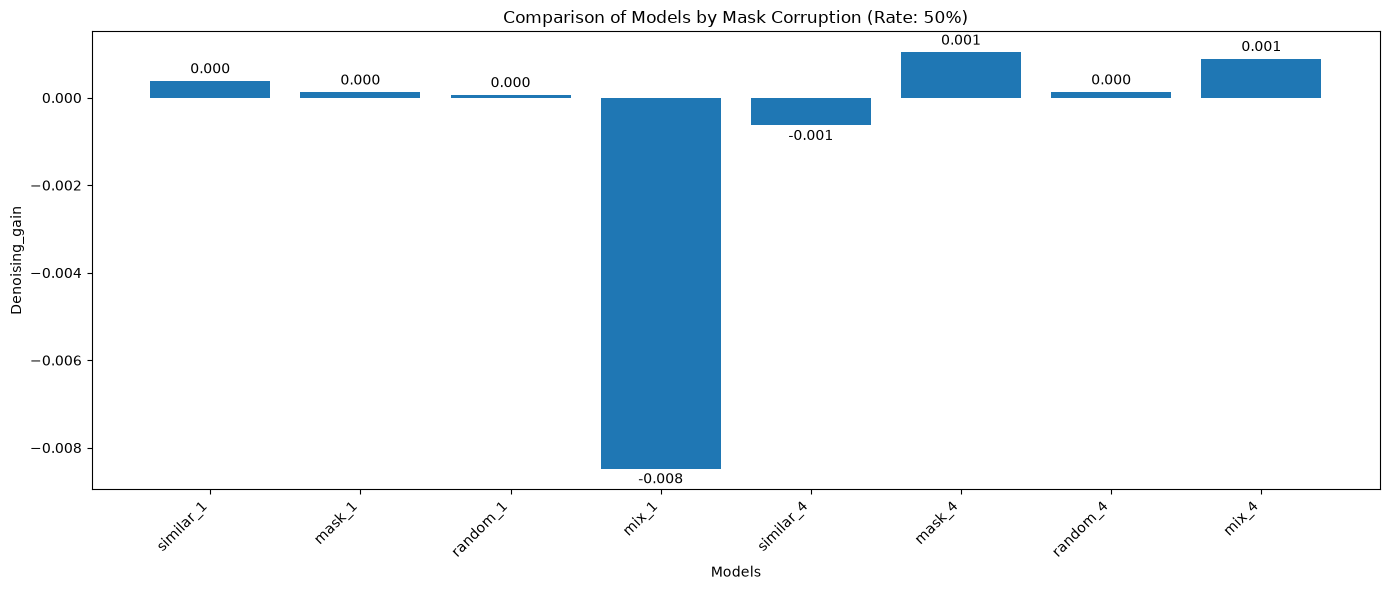

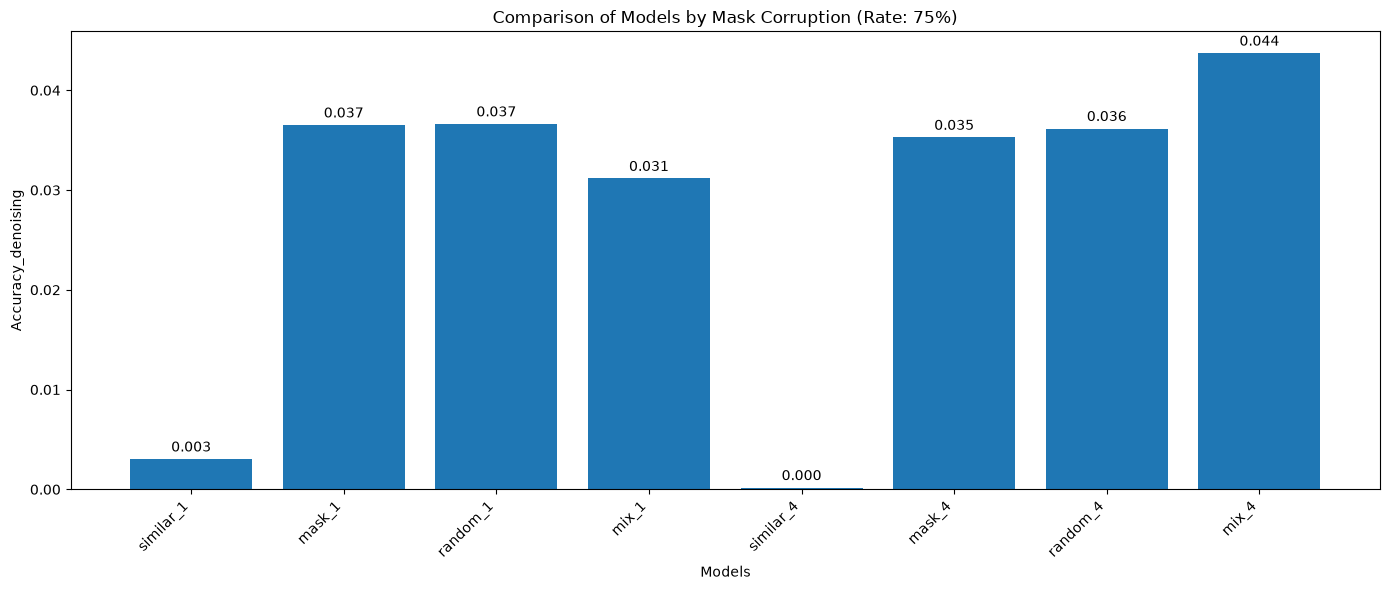

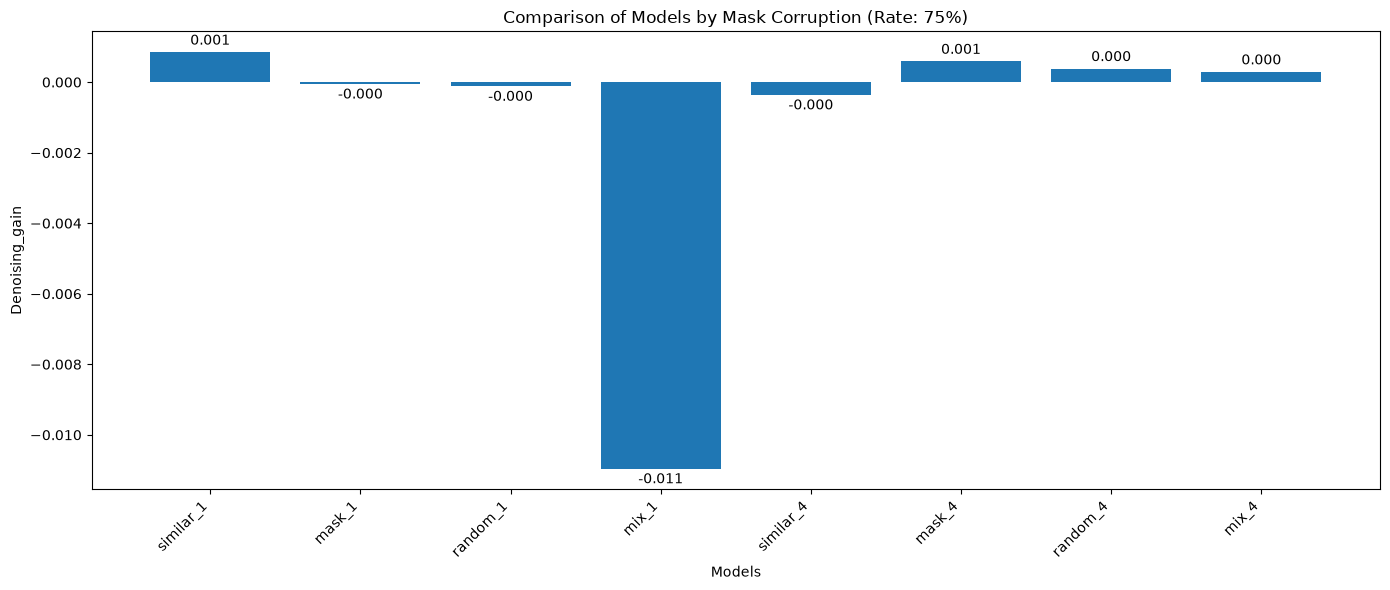

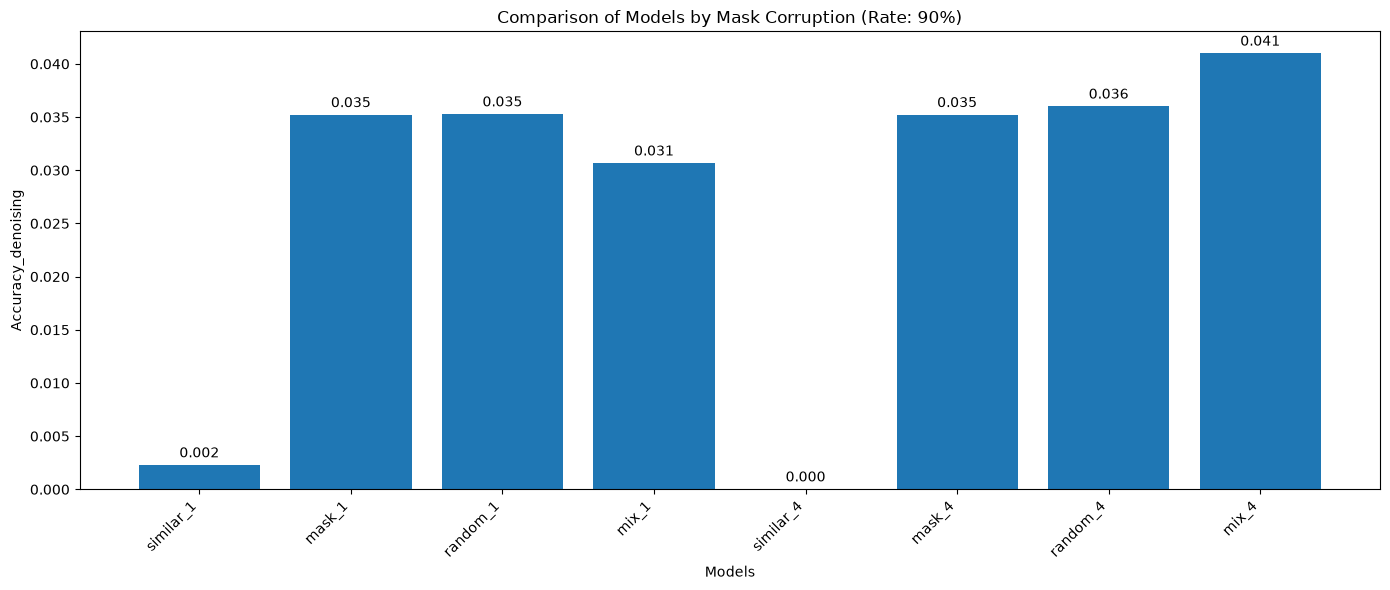

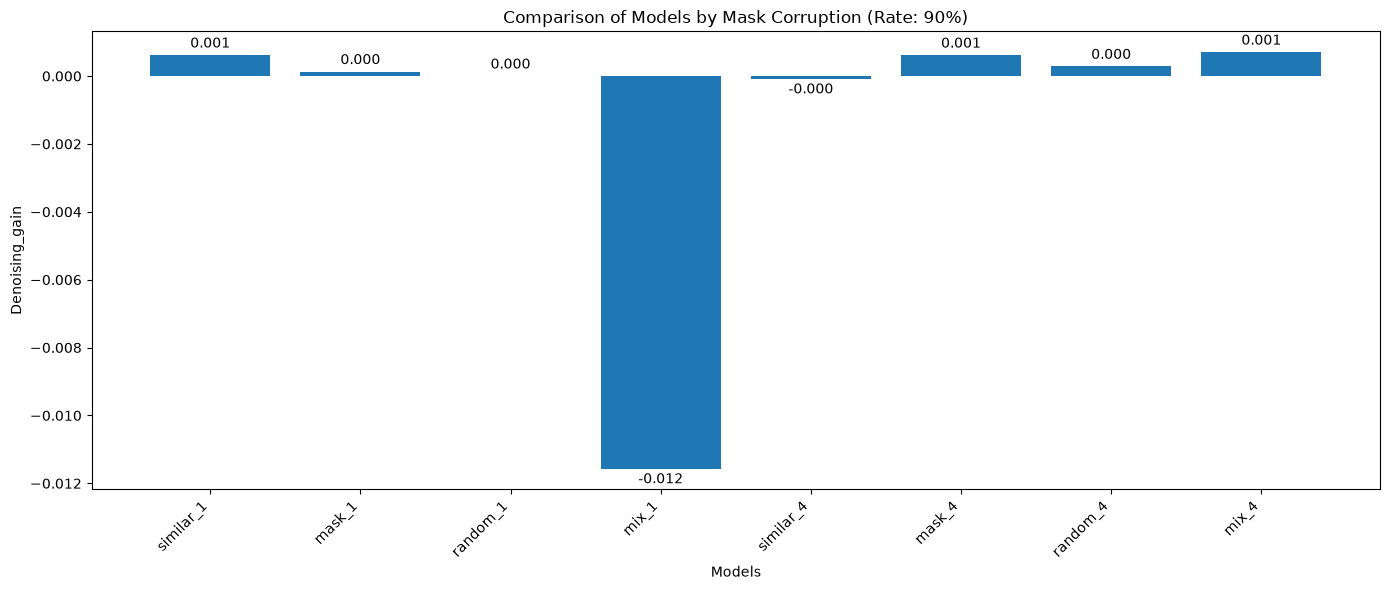

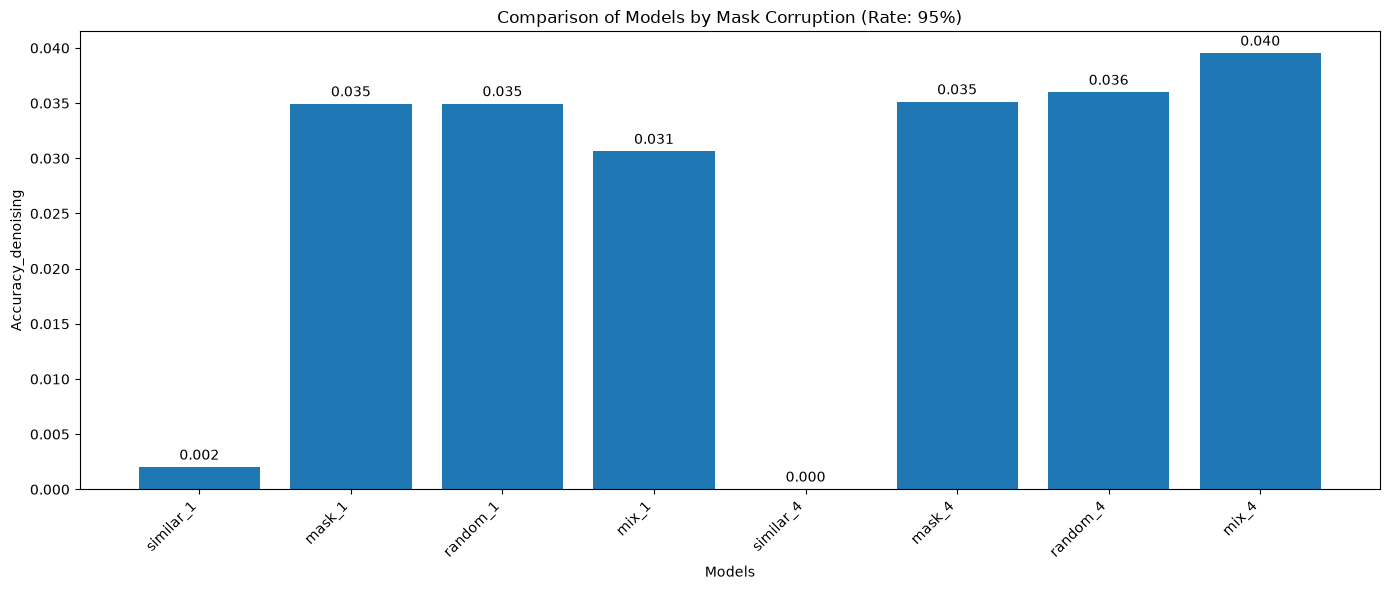

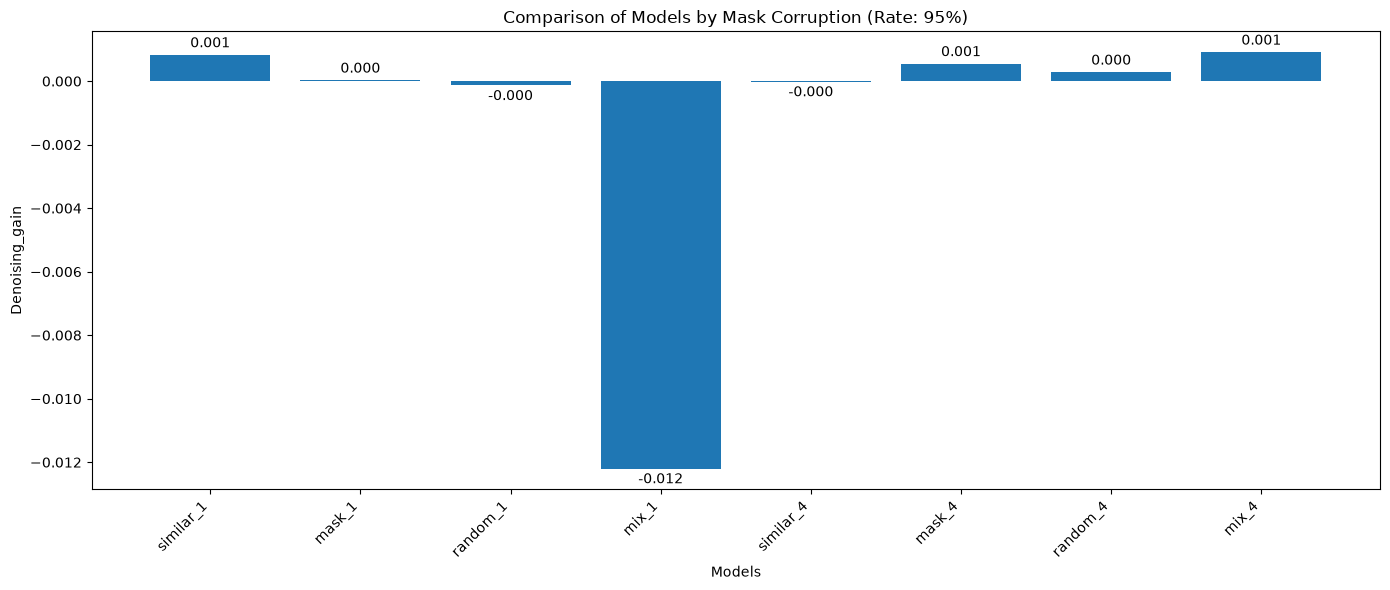

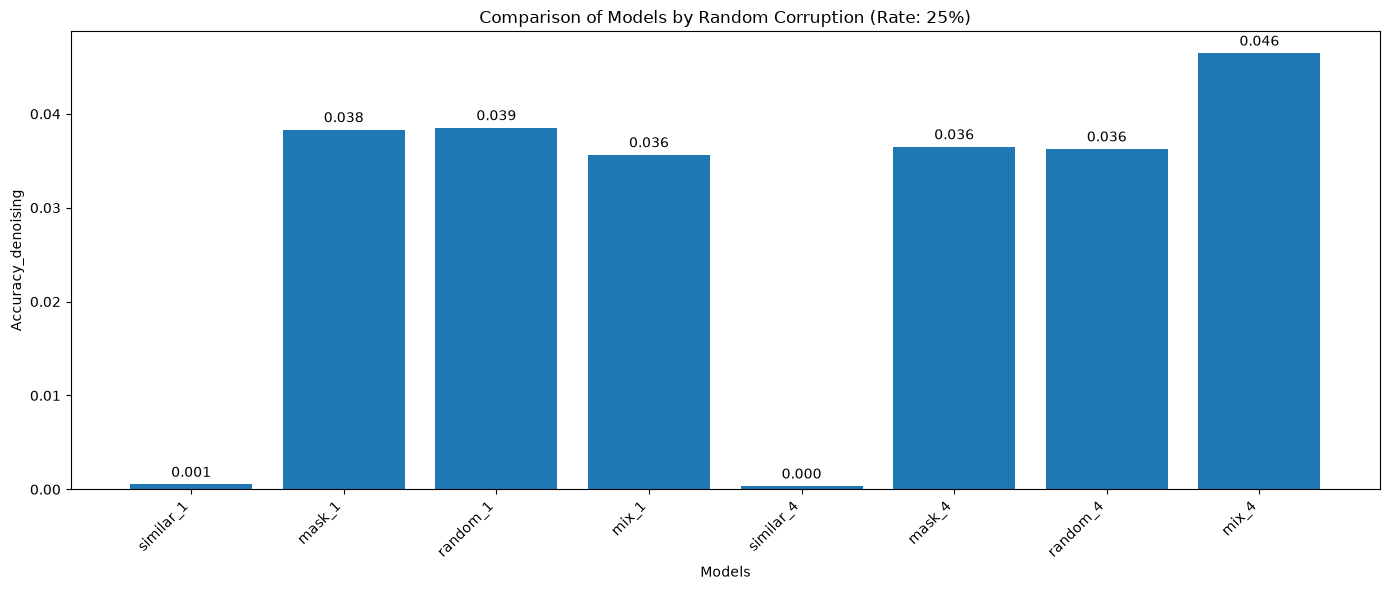

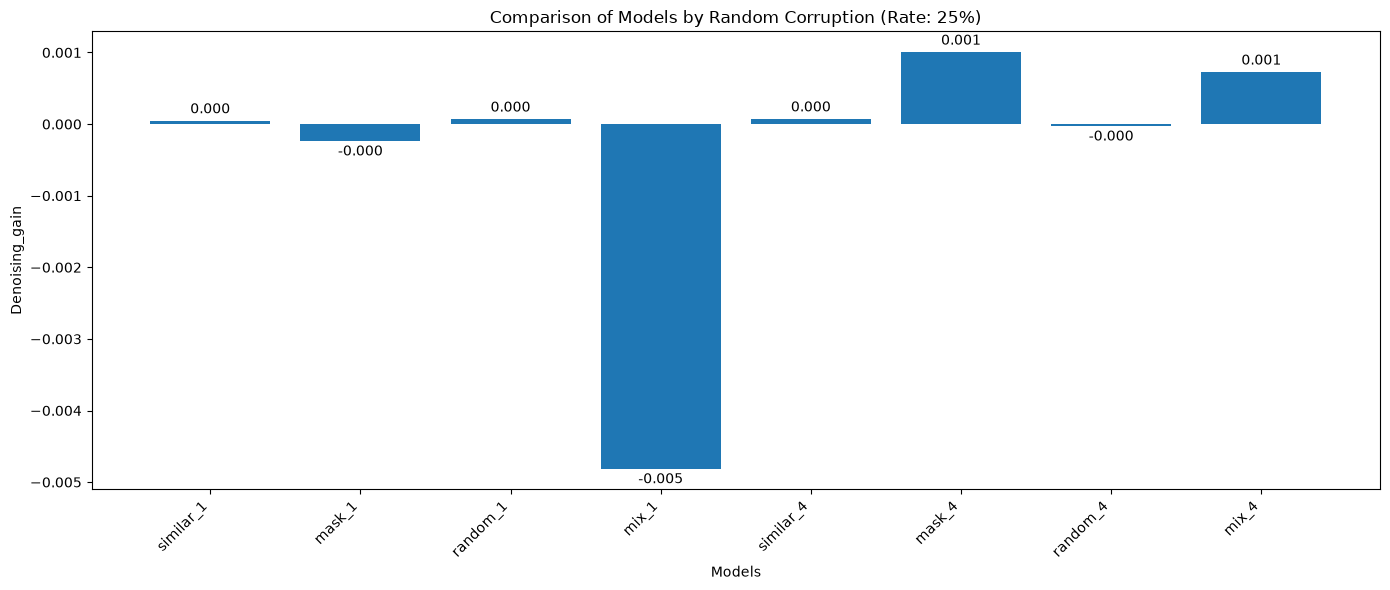

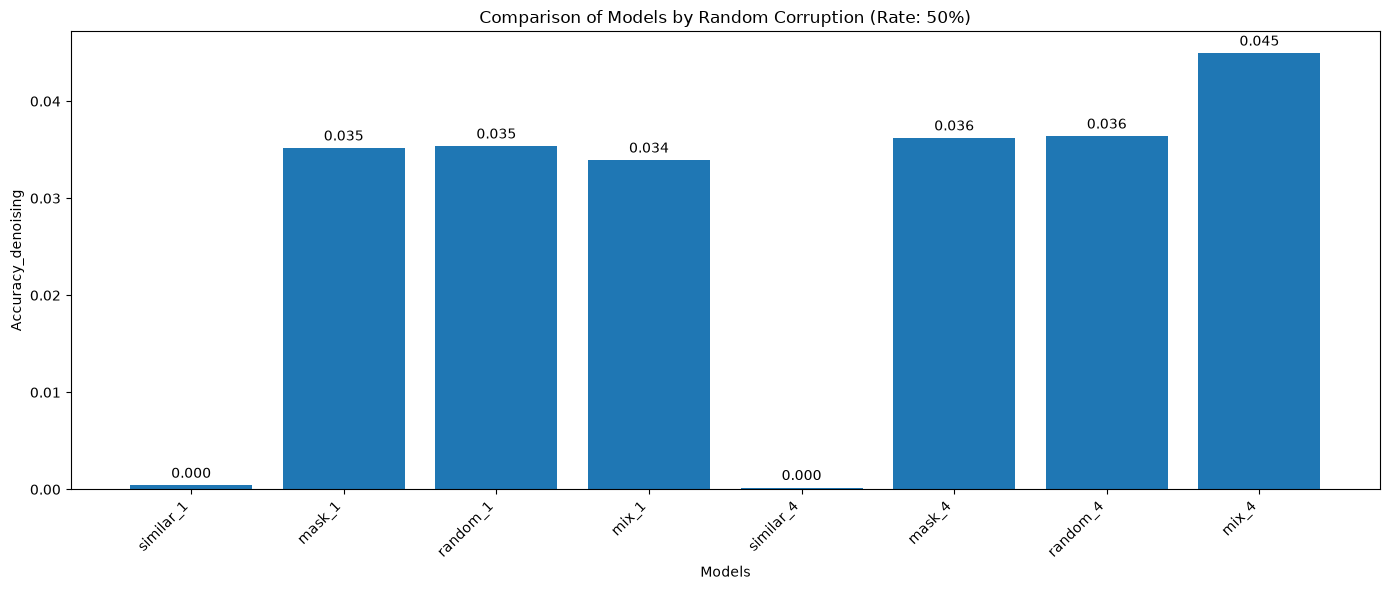

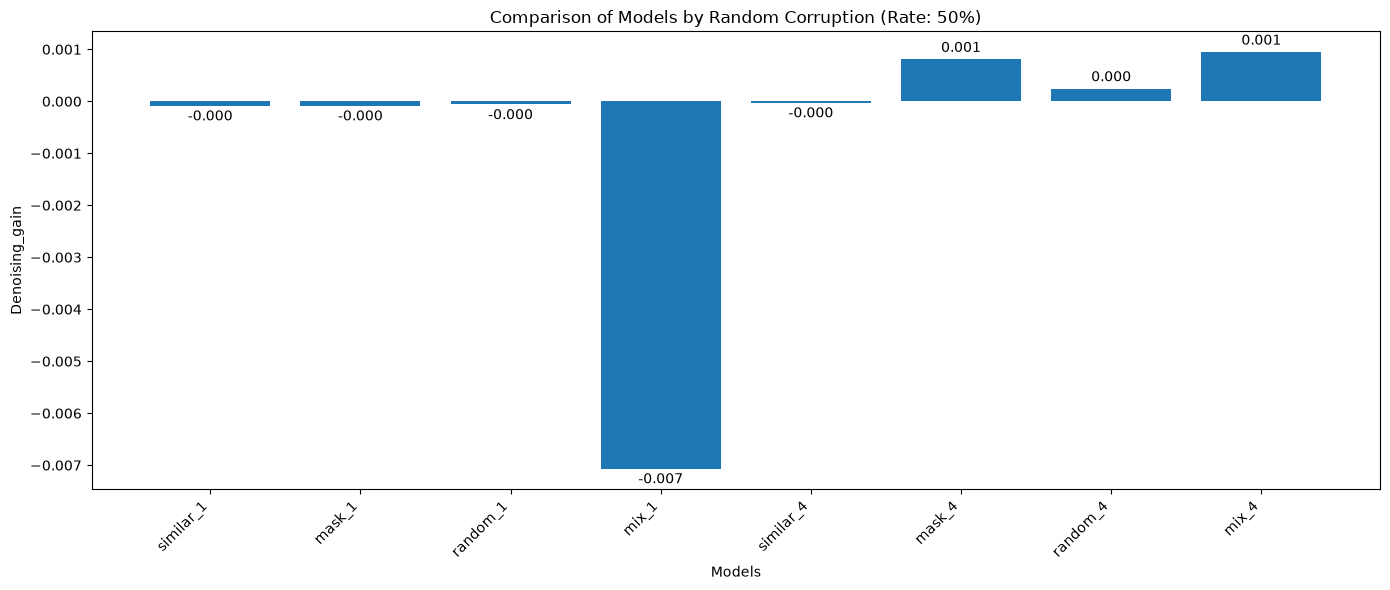

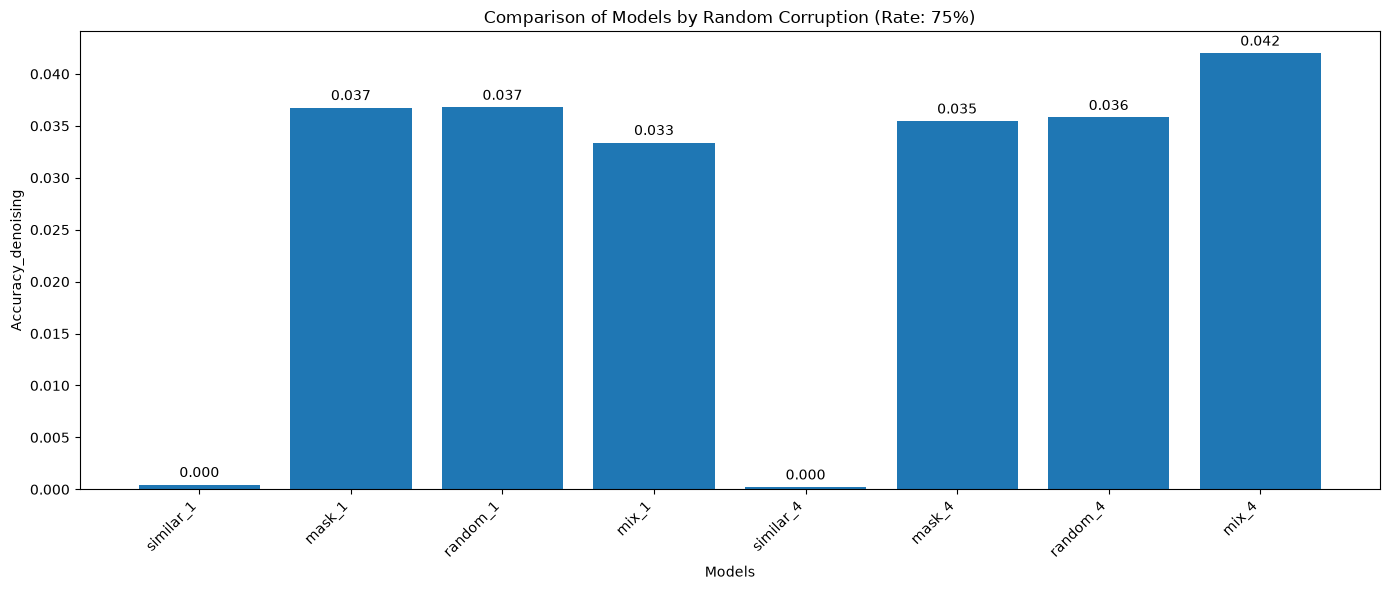

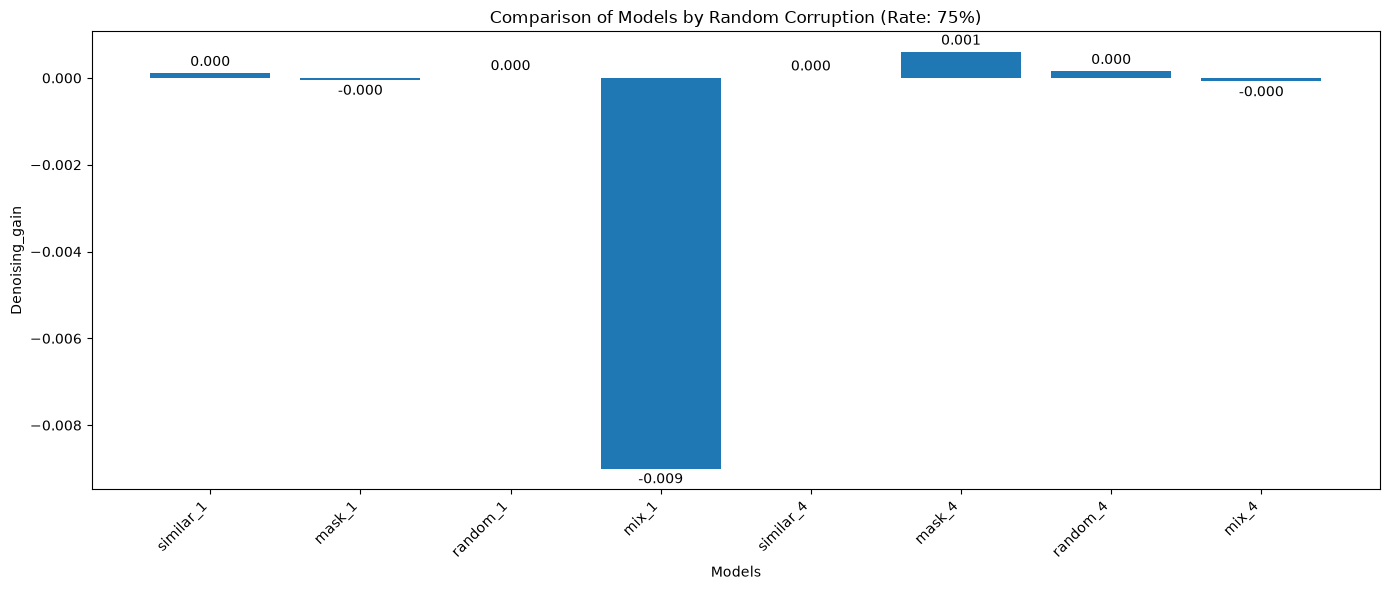

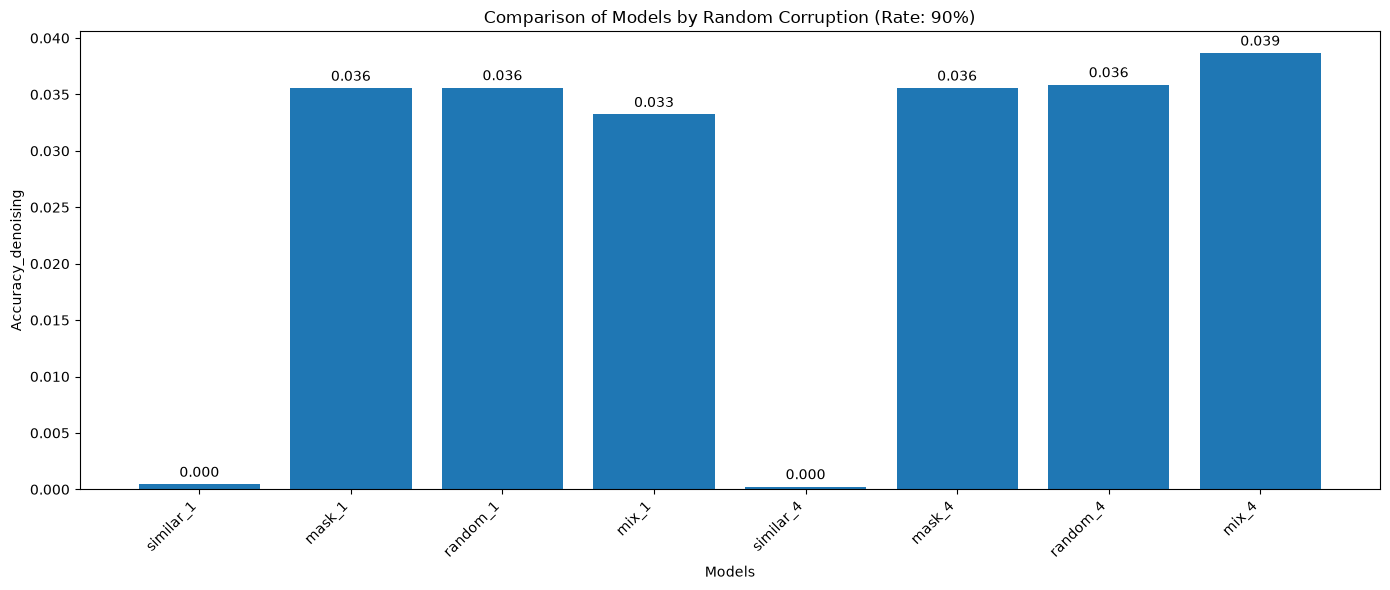

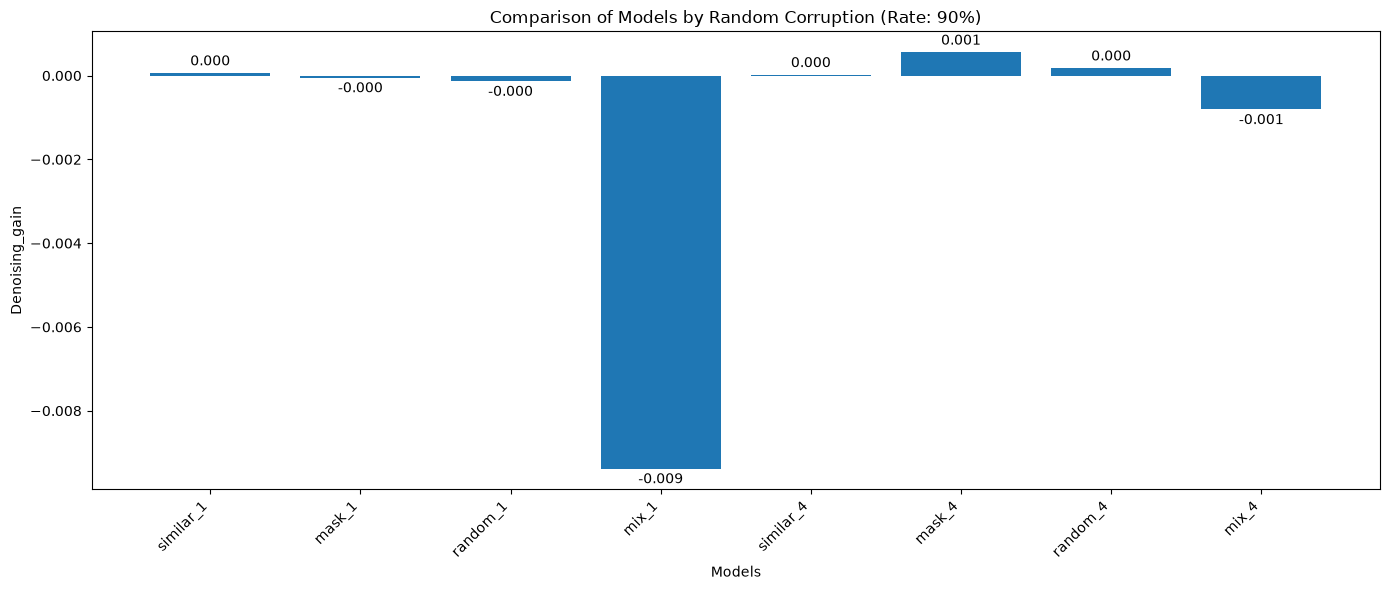

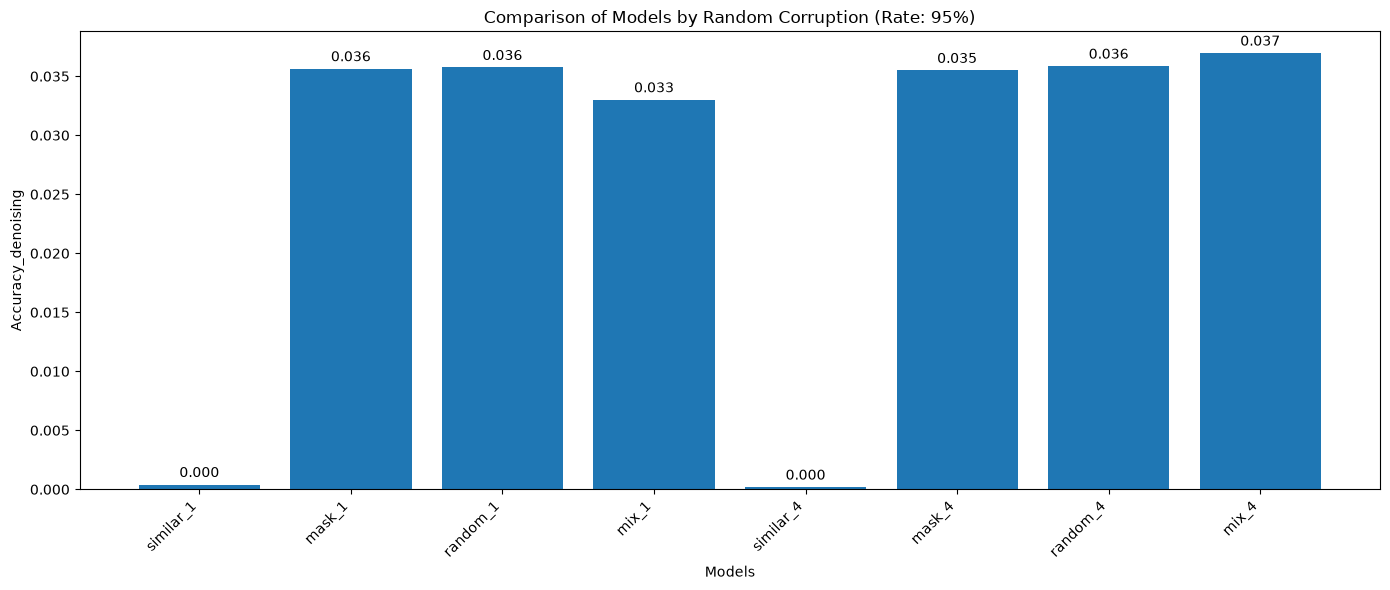

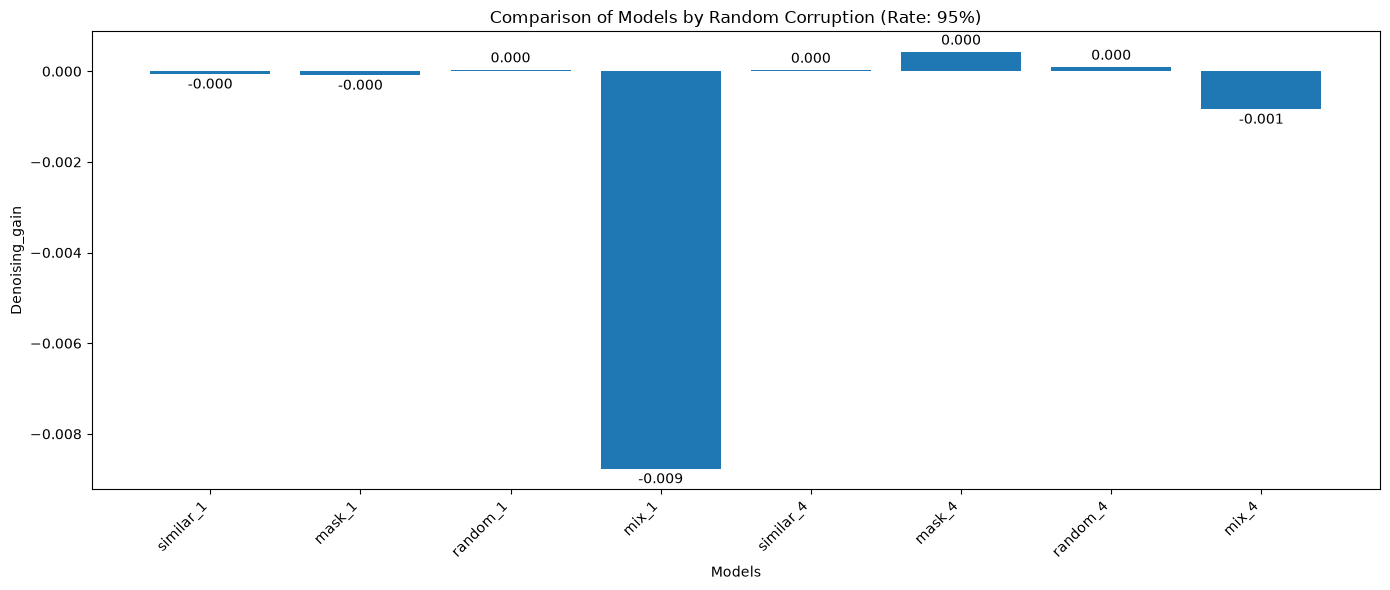

In [137]:
METHODS = df['corruption_method'].unique()
CORRUPTION_RATES = df['corruption_rate'].unique()

for method in METHODS:
    for rate in CORRUPTION_RATES:
            compare_models_by_one_metric(df, method, rate, 'accuracy_denoising')
            compare_models_by_one_metric(df, method, rate, 'denoising_gain')

## Compare metrics on random and mask corruptions 50 iterations

### Only mask corruption

In [138]:
df_mask_cr = df[df['corruption_method'].isin(['mask'])]
df_mask_cr_grouped = df_mask_cr.groupby(
    ['model']
).agg(
    {
        'loss': ['mean', 'std'],
        'accuracy': ['mean', 'std'],
        'accuracy_denoising': ['mean', 'std'],
        'denoising_gain': ['mean', 'std']
    }
).sort_values(by=('accuracy_denoising', 'mean'), ascending=False)
df_mask_cr_grouped

loss            accuracy           accuracy_denoising  \
                mean       std      mean       std               mean   
model                                                                   
mix_4       8.746837  0.165705  0.042616  0.003060           0.043340   
random_4    8.859226  0.012766  0.035892  0.000216           0.036115   
random_1    8.833546  0.010772  0.035893  0.000902           0.035830   
mask_1      9.271373  0.014332  0.035756  0.000893           0.035819   
mask_4      9.310719  0.018259  0.034822  0.000277           0.035632   
mix_1       8.562897  0.025379  0.041342  0.001535           0.031685   
similar_1  11.737527  0.447328  0.002553  0.001245           0.003156   
similar_4  12.293115  0.997173  0.000901  0.001026           0.000526   

                    denoising_gain            
                std           mean       std  
model                                         
mix_4      0.003039       0.000723  0.000255  
random_4   0.000144       0.000222  0.000142  
random_1   0.000856      -0.000063  0.000093  
mask_1     0.000860       0.000063  0.000075  
mask_4     0.000577       0.000810  0.000315  
mix_1      0.001414      -0.009657  0.002916  
similar_1  0.001037       0.000603  0.000243  
similar_4  0.000706      -0.000375  0.000341

### Only random corruption

In [141]:
df_random_cr = df[df['corruption_method'].isin(['random'])]
df_random_cr_grouped = df_random_cr.groupby(
    ['model']
).agg(
    {
        'loss': ['mean', 'std'],
        'accuracy': ['mean', 'std'],
        'accuracy_denoising': ['mean', 'std'],
        'denoising_gain': ['mean', 'std']
    }
).sort_values(by=('accuracy_denoising', 'mean'), ascending=False)
df_random_cr_grouped

loss            accuracy           accuracy_denoising  \
                mean       std      mean       std               mean   
model                                                                   
mix_4       8.827487  0.173379  0.041816  0.003241           0.041807   
random_1    8.823141  0.019159  0.036422  0.001247           0.036405   
mask_1      9.258727  0.021736  0.036385  0.001343           0.036286   
random_4    8.862827  0.009694  0.035910  0.000293           0.036037   
mask_4      9.311976  0.008840  0.035167  0.000269           0.035844   
mix_1       8.651052  0.064201  0.041642  0.000913           0.033839   
similar_1  13.909995  0.169743  0.000439  0.000064           0.000454   
similar_4  16.866574  0.979161  0.000218  0.000041           0.000237   

                    denoising_gain            
                std           mean       std  
model                                         
mix_4      0.004033      -0.000009  0.000832  
random_1   0.001303      -0.000016  0.000080  
mask_1     0.001281      -0.000098  0.000077  
random_4   0.000275       0.000128  0.000101  
mask_4     0.000477       0.000677  0.000229  
mix_1      0.001066      -0.007803  0.001894  
similar_1  0.000050       0.000015  0.000081  
similar_4  0.000067       0.000019  0.000036

### Random & mask corruption

In [140]:
df_random_mask_cr = df[df['corruption_method'].isin(['random', 'mask'])]
df_random_mask_cr_grouped = df_random_mask_cr.groupby(
    ['model']
).agg(
    {
        'loss': ['mean', 'std'],
        'accuracy': ['mean', 'std'],
        'accuracy_denoising': ['mean', 'std'],
        'denoising_gain': ['mean', 'std']
    }
).sort_values(by=('accuracy_denoising', 'mean'), ascending=False)
df_random_mask_cr_grouped

loss            accuracy           accuracy_denoising  \
                mean       std      mean       std               mean   
model                                                                   
mix_4       8.787162  0.165440  0.042216  0.003001           0.042573   
random_1    8.828343  0.015646  0.036157  0.001064           0.036118   
random_4    8.861027  0.010853  0.035901  0.000243           0.036076   
mask_1      9.265050  0.018593  0.036070  0.001125           0.036053   
mask_4      9.311347  0.013540  0.034994  0.000315           0.035738   
mix_1       8.606974  0.065398  0.041492  0.001201           0.032762   
similar_1  12.823761  1.188589  0.001496  0.001390           0.001805   
similar_4  14.579845  2.584220  0.000560  0.000773           0.000382   

                    denoising_gain            
                std           mean       std  
model                                         
mix_4      0.003462       0.000357  0.000697  
random_1   0.001083      -0.000040  0.000085  
random_4   0.000211       0.000175  0.000127  
mask_1     0.001058      -0.000018  0.000111  
mask_4     0.000512       0.000743  0.000269  
mix_1      0.001638      -0.008730  0.002515  
similar_1  0.001583       0.000309  0.000354  
similar_4  0.000497      -0.000178  0.000309

In [83]:
def plot_metric_barplots(grouped_df, figsize=(18, 12)):
    metrics = [
        ('loss', 'Loss', False),
        ('accuracy', 'Accuracy', True),
        ('accuracy_denoising', 'Denoising Accuracy', True),
        ('denoising_gain', 'Denoising Gain', True),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    models = grouped_df.index.astype(str)
    x = np.arange(len(models))

    for ax, (metric, title, higher_is_better) in zip(axes, metrics):
        means = grouped_df[(metric, 'mean')]
        stds = grouped_df[(metric, 'std')].fillna(0)

        bars = ax.bar(
            x,
            means,
            yerr=stds,
            capsize=5,
            alpha=0.85,
            edgecolor='black'
        )

        ax.set_title(title)
        ax.set_ylabel('Value')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        for bar, mean, std in zip(bars, means, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std,
                f'{mean:.4f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    fig.suptitle(
        'Comparison of Models on Random and Mask Corruptions',
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

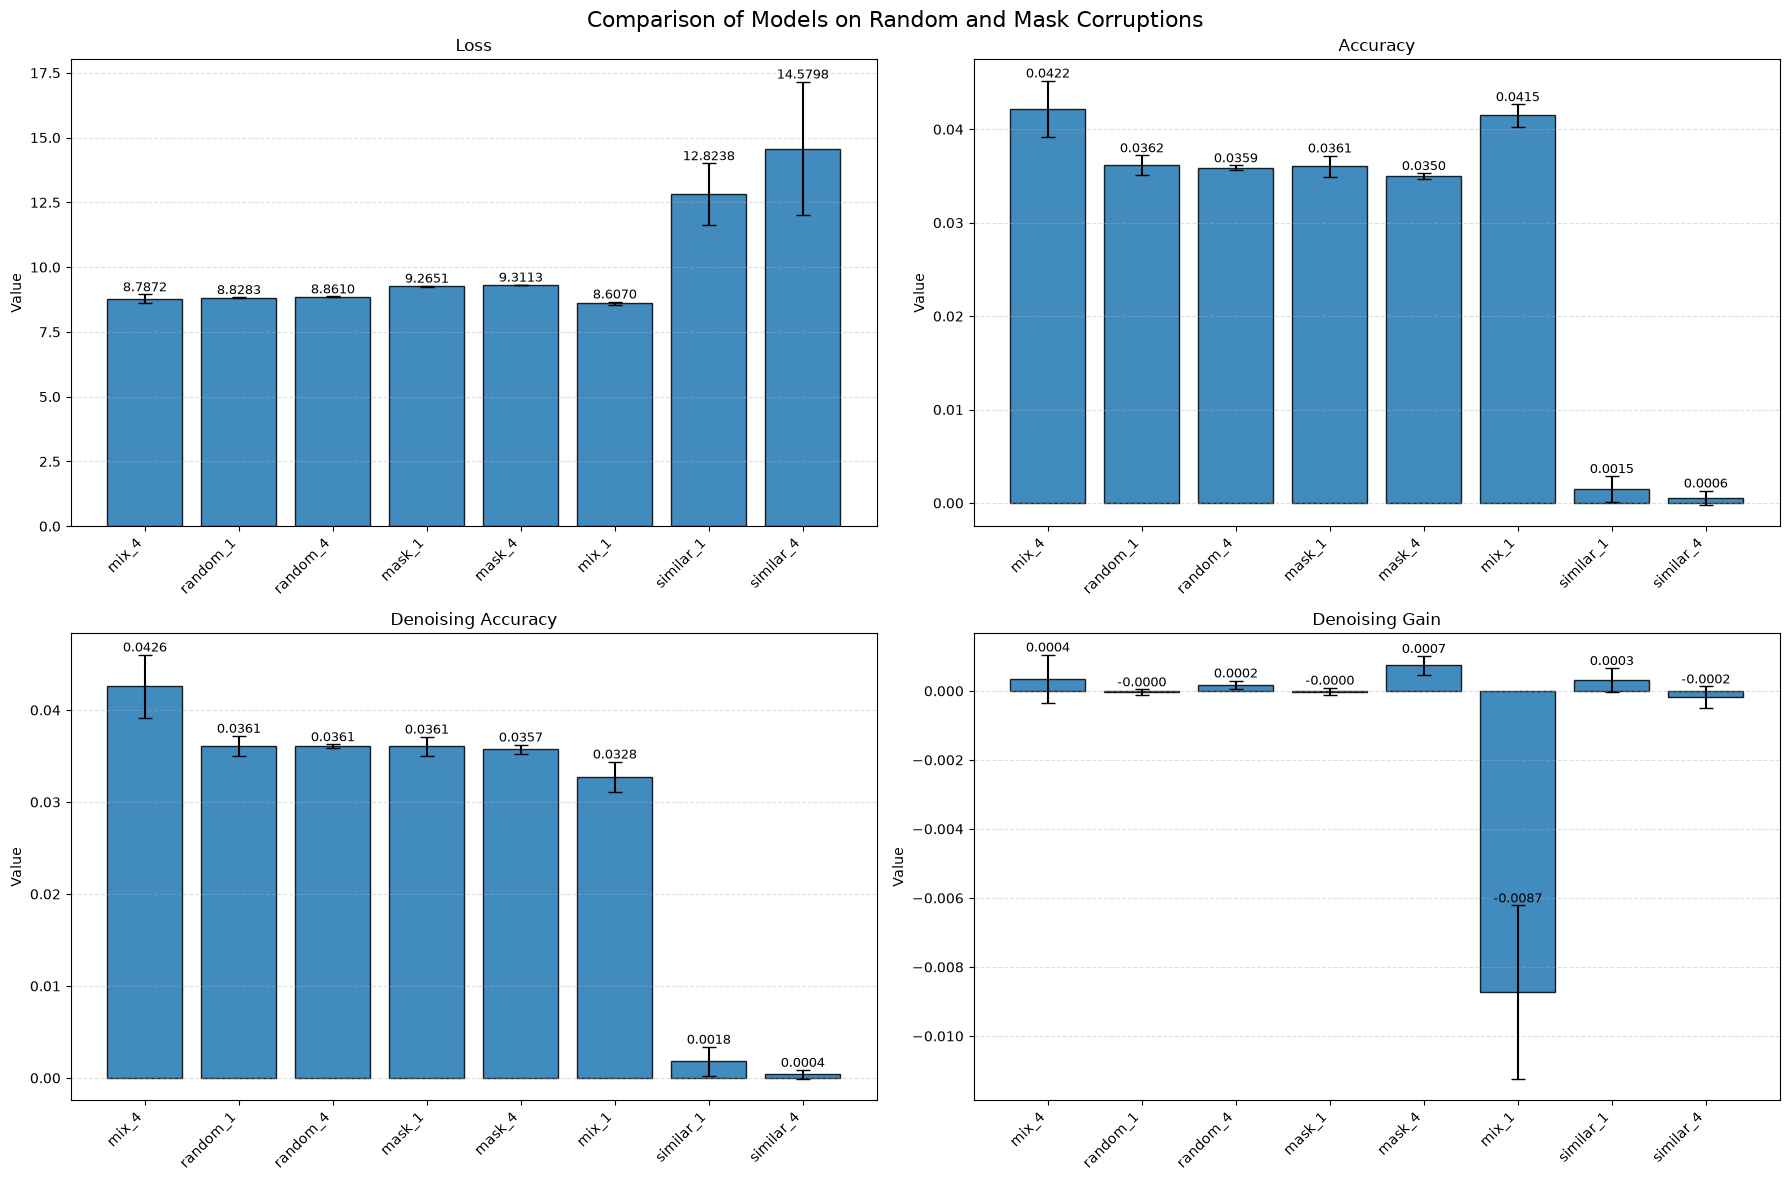

In [82]:
plot_metric_barplots(df_random_mask_cr_grouped)

## Compare models and metrics by corruption rate

In [144]:
denoising_lvls = ['2', '10', '20', '50']

df = pd.DataFrame()

for lvl in denoising_lvls:
    df_1_step = pd.read_json(f'eval/evaluation_results_{lvl}.json')
    df_1_step.model = df_1_step.model.map(lambda x: x.split('_')[0] + '_1' if '_' in x else x)
    df_1_step['denoise_iterations'] = int(lvl)
    df_4_steps = pd.read_json(f'eval/evaluation_results_{lvl}_4_steps.json')
    df_4_steps.model = df_4_steps.model.map(lambda x: x.split('_')[0] + '_4' if '_' in x else x)
    df_4_steps['denoise_iterations'] = int(lvl)
    df = pd.concat([df, df_1_step, df_4_steps], ignore_index=True)
    
df['denoising_gain'] = df['accuracy_denoising'] - df['accuracy']

In [145]:
df_random_mask_cr = df[df['corruption_method'].isin(['random', 'mask'])]
df_random_mask_cr = df_random_mask_cr.groupby(
    ['model', 'corruption_rate']
).agg(
    {
        'loss': 'mean',
        'accuracy': 'mean',
        'accuracy_denoising': 'mean',
        'denoising_gain': 'mean'
    }
).reset_index()
df_random_mask_cr.sort_values(by='accuracy_denoising', ascending=False, inplace=True)

In [146]:
def metric_by_corruption_level(df, metric):
    if metric not in POSSIBLE_METRICS:
        raise ValueError(
            f"Invalid metric '{metric}'. Valid metrics are: {POSSIBLE_METRICS}"
        )
    for model in df['model'].unique():
        model_df = df[df['model'] == model].sort_values(by='corruption_rate')
        plt.plot(
            model_df['corruption_rate'],
            model_df[metric],
            marker='o',
            label=model
        )
    ylabel = " ".join(metric.split('_')) if '_' in metric else metric
    plt.xlabel('Corruption Level')
    plt.ylabel(ylabel.capitalize())
    plt.title(f'Comparison of Models by Corruption Level for {ylabel.capitalize()}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

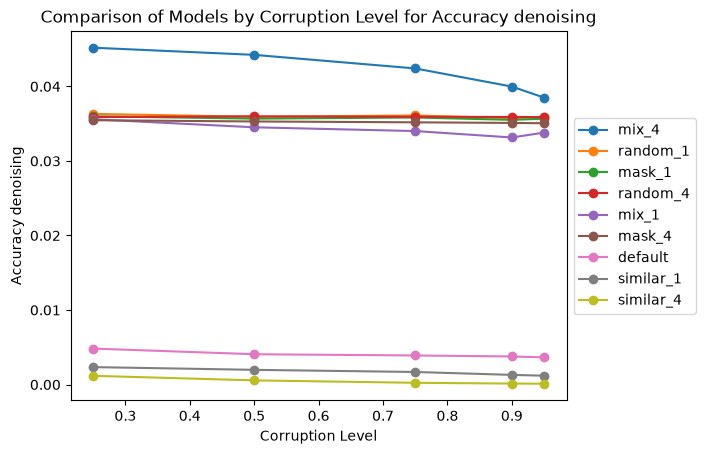

In [147]:
metric_by_corruption_level(df_random_mask_cr, 'accuracy_denoising')

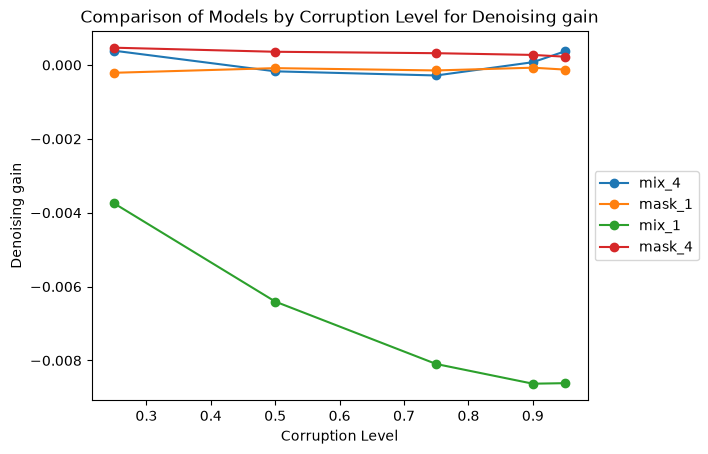

In [148]:
metric_by_corruption_level(df_random_mask_cr[df_random_mask_cr.model.isin(['mask_4', 'mask_1', 'mix_4', 'mix_1'])], 'denoising_gain')

## Compare models and metrics by denoising lvl

In [149]:
df_random_mask_cr = df[df['corruption_method'].isin(['random', 'mask'])]
df_random_mask_cr_grouped_denoise = df_random_mask_cr.groupby(
    ['model', 'denoise_iterations']
).agg(
    {
        'loss': 'mean',
        'accuracy': 'mean',
        'accuracy_denoising': 'mean',
        'denoising_gain': 'mean'
    }
).reset_index()

def metric_by_denoise_level(df, metric):
    if metric not in POSSIBLE_METRICS:
        raise ValueError(
            f"Invalid metric '{metric}'. Valid metrics are: {POSSIBLE_METRICS}"
        )
    for model in df['model'].unique():
        model_df = df[df['model'] == model].sort_values(by='denoise_iterations')
        plt.plot(
            model_df['denoise_iterations'],
            model_df[metric],
            marker='o',
            label=model
        )
    ylabel = " ".join(metric.split('_')) if '_' in metric else metric
    plt.xlabel('Denoise Level')
    plt.ylabel(ylabel.capitalize())
    plt.title(f'Comparison of Models by Denoise Level for {ylabel.capitalize()}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

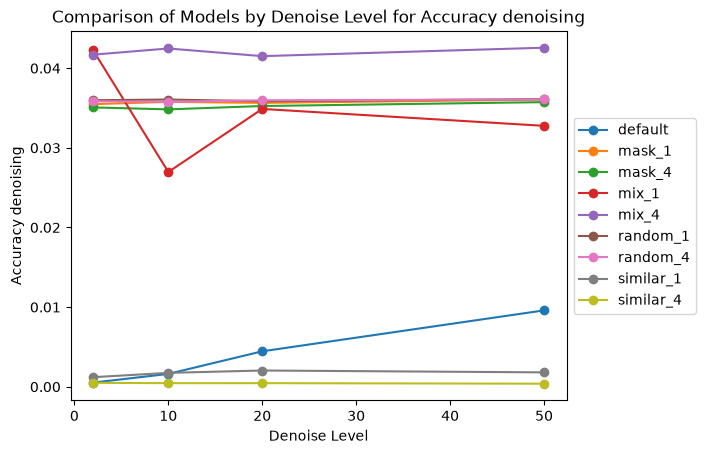

In [150]:
metric_by_denoise_level(df_random_mask_cr_grouped_denoise, 'accuracy_denoising')

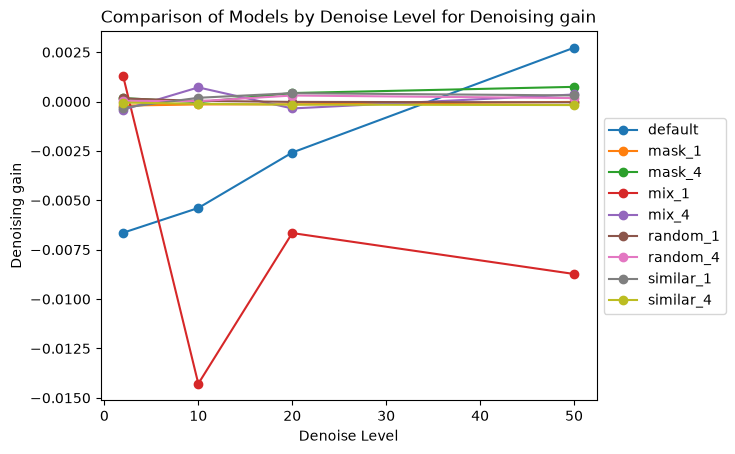

In [151]:
metric_by_denoise_level(df_random_mask_cr_grouped_denoise, 'denoising_gain')

### heatmap

In [ ]:
def plot_iteration_heatmap(
    df,
    metric='denoising_gain',
    methods=('random', 'mask'),
    figsize=(10, 6)
):
    data = df[df['corruption_method'].isin(methods)].copy()

    heatmap_data = (
        data
        .groupby(['model', 'denoise_iterations'])[metric]
        .mean()
        .unstack('denoise_iterations')
        .sort_index()
    )

    # Display denoising gain in percentage points
    if metric == 'denoising_gain':
        display_data = heatmap_data * 100
    else:
        display_data = heatmap_data

    fig, ax = plt.subplots(figsize=figsize)

    if metric == 'denoising_gain':
        max_abs = np.nanmax(np.abs(display_data.to_numpy()))

        norm = SymLogNorm(
            linthresh=0.02,
            linscale=1.5,
            vmin=-max_abs,
            vmax=max_abs,
            base=10
        )
        cmap = 'RdBu_r'
        colorbar_label = 'Denoising gain (percentage points)'
    else:
        norm = None
        cmap = 'viridis'
        colorbar_label = metric.replace('_', ' ').title()

    image = ax.imshow(
        display_data.to_numpy(),
        aspect='auto',
        cmap=cmap,
        norm=norm
    )

    ax.set_xticks(np.arange(len(display_data.columns)))
    ax.set_xticklabels(display_data.columns)

    ax.set_yticks(np.arange(len(display_data.index)))
    ax.set_yticklabels(display_data.index)

    ax.set_xlabel('Number of denoising iterations')
    ax.set_ylabel('Model')
    ax.set_title(
        f'{metric.replace("_", " ").title()} by Model and Iterations'
    )

    for i in range(display_data.shape[0]):
        for j in range(display_data.shape[1]):
            value = display_data.iloc[i, j]

            if not np.isnan(value):
                rgba = image.cmap(image.norm(value))
                luminance = (
                    0.299 * rgba[0]
                    + 0.587 * rgba[1]
                    + 0.114 * rgba[2]
                )

                ax.text(
                    j,
                    i,
                    f'{value:.3f}' if metric == 'denoising_gain'
                    else f'{value:.4f}',
                    ha='center',
                    va='center',
                    color='white' if luminance < 0.5 else 'black'
                )

    fig.colorbar(
        image,
        ax=ax,
        label=colorbar_label
    )

    plt.tight_layout()
    plt.show()

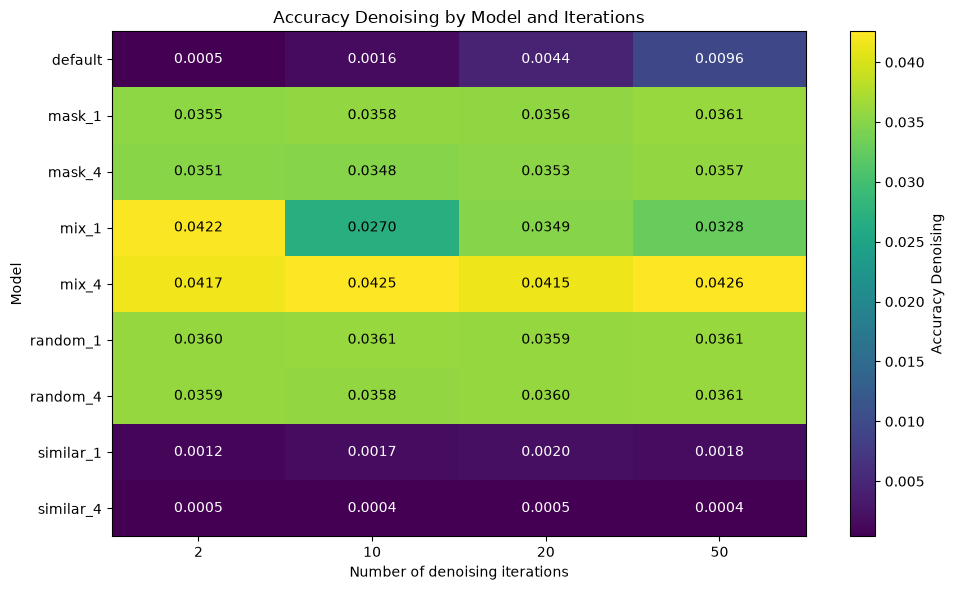

In [156]:
plot_iteration_heatmap(
    df,
    metric='accuracy_denoising'
)

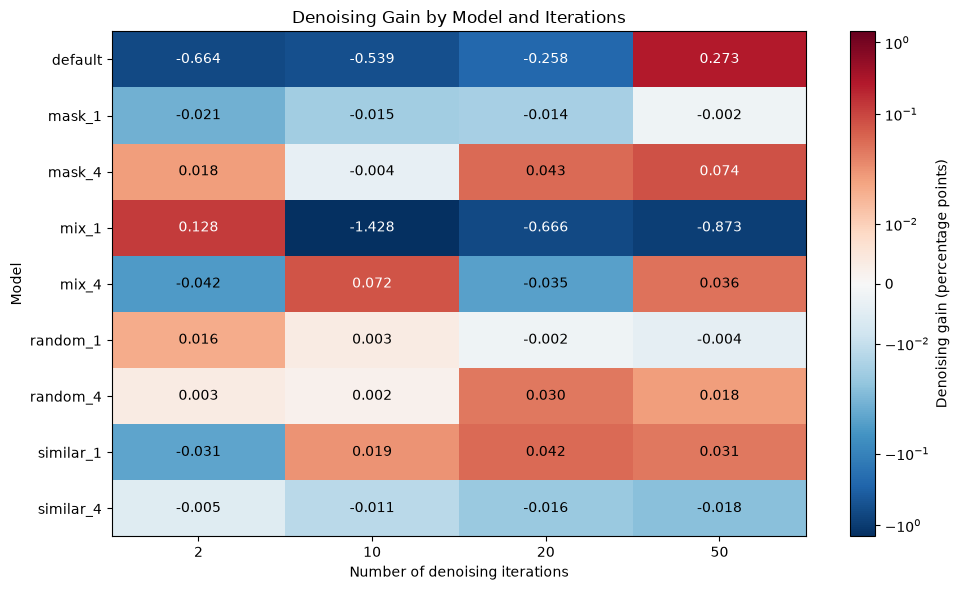

In [157]:
plot_iteration_heatmap(
    df,
    metric='denoising_gain'
)

## AUC iterations

### AUC over denoising iterations

The Area Under the Curve (AUC) summarizes the overall denoising performance across different numbers of denoising iterations. It is calculated from the curve of `accuracy_denoising` versus `denoise_iterations`.

A higher AUC indicates better average performance across the evaluated iteration levels, rather than at only one specific number of iterations.

In [162]:
df.head()

,model,model_path,dataset,split,corruption_method,corruption_rate,loss,accuracy,num_positions,accuracy_denoising,denoise_iterations,num_denoising_positions,seed,initial_timestep,denoising_gain
0,default,results/models/default.pt,cimec/lambada,test,similar,0.25,8.414945,0.009855,42617,0.000305,2,42617,NaN,NaN,-0.009550
1,similar_1,results/models/similar_100.pt,cimec/lambada,test,similar,0.25,4.768562,0.241218,42617,0.226506,2,42617,NaN,NaN,-0.014712
2,mask_1,results/models/mask_100.pt,cimec/lambada,test,similar,0.25,9.200795,0.036910,42617,0.036676,2,42617,NaN,NaN,-0.000235
3,random_1,results/models/random_100.pt,cimec/lambada,test,similar,0.25,8.780379,0.037027,42617,0.036746,2,42617,NaN,NaN,-0.000282
4,mix_1,results/models/mix_30_30_40.pt,cimec/lambada,test,similar,0.25,8.376829,0.064669,42617,0.059178,2,42617,NaN,NaN,-0.005491


In [ ]:
auc_data = df[
    df['corruption_method'].isin(['random', 'mask'])
].copy()

iteration_curves = (
    auc_data
    .groupby(['model', 'denoise_iterations'])['accuracy_denoising']
    .mean()
    .reset_index()
)

# Calculate AUC for every model
auc_results = []

for model, model_df in iteration_curves.groupby('model'):
    model_df = model_df.sort_values('denoise_iterations')

    x = model_df['denoise_iterations'].to_numpy()
    y = model_df['accuracy_denoising'].to_numpy()

    auc = np.trapezoid(y, x)

    # Normalized AUC = average accuracy over the iteration range
    normalized_auc = auc / (x[-1] - x[0])

    auc_results.append({
        'model': model,
        'auc_iterations': auc,
        'normalized_auc_iterations': normalized_auc
    })

auc_iterations_df = (
    pd.DataFrame(auc_results)
    .sort_values(
        'normalized_auc_iterations',
        ascending=False
    )
)

auc_iterations_df

,model,auc_iterations,normalized_auc_iterations
4,mix_4,2.017924,0.042040
5,random_1,1.727298,0.035985
6,random_4,1.726004,0.035958
1,mask_1,1.717601,0.035783
2,mask_4,1.694834,0.035309
3,mix_1,1.600777,0.033350
0,default,0.249387,0.005196
7,similar_1,0.088311,0.001840
8,similar_4,0.020746,0.000432


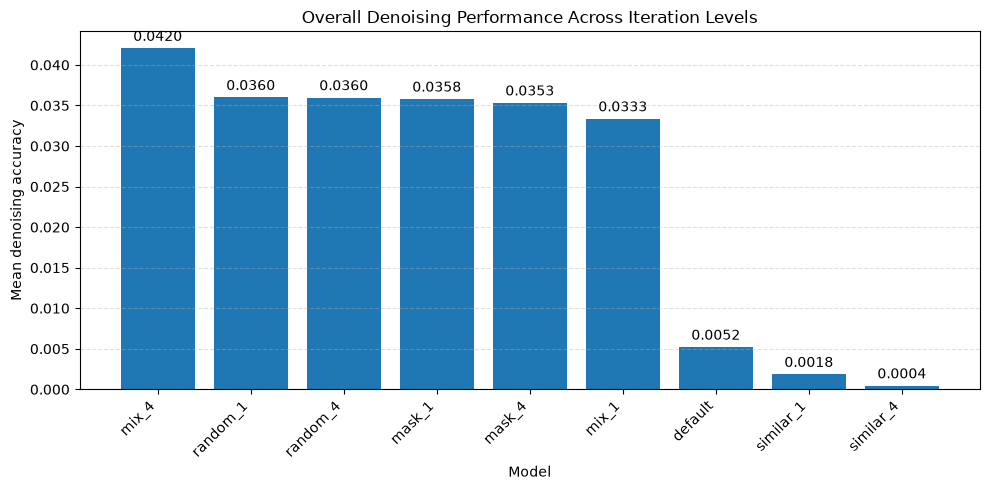

In [164]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    auc_iterations_df['model'],
    auc_iterations_df['normalized_auc_iterations']
)

plt.ylabel('Mean denoising accuracy')
plt.xlabel('Model')
plt.title('Overall Denoising Performance Across Iteration Levels')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.bar_label(bars, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()